# First-Trimester Pregnancy-Loss Prediction — End-to-End Pipeline

**FETA-Transformer + PREG-Net + Ensemble**

This single notebook reproduces the whole project from scratch, one layer at a time.
Each layer is self-contained: run the cells top-to-bottom and every artifact
(data → models → results) is regenerated.


---
## Layer 1 — Data

Two steps:
1. **Acquire public reference datasets** — the clinical literature/data that *motivates* our biological growth curves.
2. **Generate the synthetic cohort** — the actual data the models train on.

### 0. Environment setup

The first cell to run. The `%pip install` line is commented out — uncomment it on a
fresh machine, then re-comment it so later runs stay fast. The cell imports the standard
scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), sets a consistent Seaborn
plotting theme, and creates the two output folders the pipeline writes to:

- `datasets/` — public reference downloads (Step 1),
- `data/generated/` — the synthetic cohort the models actually read (Step 2).

`torch` is deliberately **not** imported here; it first appears in Layer 2, the earliest
layer that needs it.

In [1]:
# First run only — uncomment to install:
# %pip install numpy pandas matplotlib seaborn requests

import os
import math
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Project-root-relative output locations
DATASETS_DIR = Path("datasets")          # public reference downloads
GENERATED_DIR = Path("data/generated")   # synthetic cohort (models read from here)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print("numpy", np.__version__, "| pandas", pd.__version__)

Environment ready.
numpy 2.4.1 | pandas 3.0.0


### Step 1 — Acquire public reference datasets

We pull the openly available fetal/pregnancy datasets that inform this work
(cardiotocography FHR data, longitudinal CTG archives, CRL image sets, maternal-feature tables).

> **What these actually contribute.** These public sources *ground and motivate* the
> published clinical growth-curve equations used in Step 2 (Hadlock, Nyberg, Doubilet &
> Benson, Blaas). The synthetic generator in Step 2 is **formula-based** — it does not read
> these files directly. They are included here for provenance and so the pipeline documents
> where the biological priors come from. Downloads are best-effort: failures are logged, not fatal.

Toggle the flags below to control what gets fetched.

In [2]:
import requests

DOWNLOAD_REFERENCE_DATA = True    # attempt downloads at all
FETCH_LARGE_ARCHIVES    = False   # also pull the big .zip/.tar.gz archives (slow)

# name -> (url, size_class, note).  size_class in {small, large, placeholder}
REFERENCE_SOURCES = {
    "Detti2020.pdf":                 ("https://www.nature.com/articles/s41598-020-58114-3.pdf",                              "small",       "Detti et al. 2020 — early-pregnancy US reference (paper)"),
    "cardiotocography.zip":          ("https://archive.ics.uci.edu/static/public/193/cardiotocography.zip",                 "large",       "UCI Cardiotocography — FHR baseline / variability"),
    "CTGDL_ctu_uhb_csv.tar.gz":      ("https://zenodo.org/record/18034361/files/CTGDL_ctu_uhb_csv.tar.gz?download=1",       "large",       "CTGDL CTU-UHB FHR archive"),
    "CTGDL_FHRMA_ano_csv.tar.gz":    ("https://zenodo.org/record/18034361/files/CTGDL_FHRMA_ano_csv.tar.gz?download=1",     "large",       "CTGDL FHRMA annotated archive"),
    "CTGDL_norm_metadata.csv":       ("https://zenodo.org/record/18034361/files/CTGDL_norm_metadata.csv?download=1",        "small",       "CTGDL normal metadata"),
    "CTGDL_SPAM_metadata.csv":       ("https://zenodo.org/record/18034361/files/CTGDL_SPAM_metadata.csv?download=1",        "small",       "CTGDL SPAM metadata"),
    "CRL_images.zip":                ("https://figshare.com/ndownloader/files/16570518",                                    "large",       "Fetal CRL ultrasound image set"),
    "HibaAsri.xlsx":                 ("UNSPECIFIED_MENDELEY_URL",                                                           "placeholder", "Hiba Asri maternal features — Mendeley URL must be supplied manually"),
}

def fetch(name, url, timeout=30):
    """Best-effort download to datasets/<name>. Returns a status string."""
    dest = DATASETS_DIR / name
    if dest.exists() and dest.stat().st_size > 0:
        return f"cached ({dest.stat().st_size/1e6:.1f} MB)"
    try:
        with requests.get(url, stream=True, timeout=timeout,
                          headers={"User-Agent": "research-notebook"}) as r:
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 16):
                    f.write(chunk)
        return f"downloaded ({dest.stat().st_size/1e6:.1f} MB)"
    except Exception as e:
        if dest.exists():
            dest.unlink()  # remove partial
        return f"FAILED — {type(e).__name__}: {e}"

manifest = []
for name, (url, size_class, note) in REFERENCE_SOURCES.items():
    if not DOWNLOAD_REFERENCE_DATA:
        status = "skipped (downloads disabled)"
    elif size_class == "placeholder":
        status = "skipped (placeholder URL — supply manually)"
    elif size_class == "large" and not FETCH_LARGE_ARCHIVES:
        status = "skipped (large archive — set FETCH_LARGE_ARCHIVES=True)"
    else:
        status = fetch(name, url)
    manifest.append({"file": name, "size_class": size_class, "status": status, "note": note})

manifest_df = pd.DataFrame(manifest)
print("Public reference dataset acquisition:\n")
for _, row in manifest_df.iterrows():
    print(f"  [{row['status']:<45}] {row['file']}")
manifest_df[["file", "size_class", "status"]]

Public reference dataset acquisition:

  [cached (1.8 MB)                              ] Detti2020.pdf
  [skipped (large archive — set FETCH_LARGE_ARCHIVES=True)] cardiotocography.zip
  [skipped (large archive — set FETCH_LARGE_ARCHIVES=True)] CTGDL_ctu_uhb_csv.tar.gz
  [skipped (large archive — set FETCH_LARGE_ARCHIVES=True)] CTGDL_FHRMA_ano_csv.tar.gz
  [cached (0.1 MB)                              ] CTGDL_norm_metadata.csv
  [cached (0.0 MB)                              ] CTGDL_SPAM_metadata.csv
  [skipped (large archive — set FETCH_LARGE_ARCHIVES=True)] CRL_images.zip
  [skipped (placeholder URL — supply manually)  ] HibaAsri.xlsx


,file,size_class,status
0,Detti2020.pdf,small,cached (1.8 MB)
1,cardiotocography.zip,large,skipped (large archive — set FETCH_LARGE_ARCHI...
2,CTGDL_ctu_uhb_csv.tar.gz,large,skipped (large archive — set FETCH_LARGE_ARCHI...
3,CTGDL_FHRMA_ano_csv.tar.gz,large,skipped (large archive — set FETCH_LARGE_ARCHI...
4,CTGDL_norm_metadata.csv,small,cached (0.1 MB)
5,CTGDL_SPAM_metadata.csv,small,cached (0.0 MB)
6,CRL_images.zip,large,skipped (large archive — set FETCH_LARGE_ARCHI...
7,HibaAsri.xlsx,placeholder,skipped (placeholder URL — supply manually)


The synthetic generator below stands on its own — nothing above is required for it to run.
If some downloads failed (network, dead mirror, placeholder URL), that has **no effect** on
the data the models see. Proceed to Step 2.

### Step 2 — Generate the synthetic first-trimester cohort

The data layer proper. We fabricate **800 patients** (~22% pregnancy loss), each with **2–5
longitudinal ultrasound scans**, from published clinical reference equations plus programmed,
label-dependent latent biology.

**Biological basis (literature-derived curves):**

| Variable | Model | Reference |
|----------|-------|-----------|
| **CRL** (crown-rump length) | polynomial in GA | Robinson & Fleming 1975; Hadlock 1992 |
| **GS** (gestational sac) | exponential growth | Nyberg 1987; Hellman 1969 |
| **FHR** (fetal heart rate) | parabolic rise-then-plateau, peak ~wk 9 | Doubilet & Benson 1995 |
| **YSD** (yolk sac diameter) | grows wk 5–10 then involutes | Blaas 1995; Cyr 1988 |

**Design principles:** patient-level latent factors (growth / heart / placenta / noise);
label-dependent but **overlapping** distributions (so classification is non-trivial);
autoregressive scan-to-scan dependency; correlated maternal features; clinically plausible,
GA- and outcome-dependent missingness; all values clamped to first-trimester ranges.

#### 2.1 Configuration & reproducibility

Seeds `random` and `numpy` (`SEED = 42`) so the cohort is reproducible run-to-run, then
fixes every knob the generator uses: cohort size (**800 patients**, ~22% loss target), the
2–5 scans-per-patient range and their gestational-age spacing, the first-trimester clinical
ranges each measurement is clamped to, and the per-variable measurement-error SDs — tighter
for CRL/YSD, looser for GS/FHR, mirroring real ultrasound precision.

In [3]:
# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── configuration ────────────────────────────────────────────────────────────
N_PATIENTS        = 800
LOSS_RATE_TARGET  = 0.22        # aim for ~20-25%
MIN_SCANS         = 2
MAX_SCANS         = 5
GA_FIRST_SCAN_MU  = 6.5         # mean GA of first scan (weeks)
GA_FIRST_SCAN_SD  = 0.7
INTER_SCAN_MU     = 2.0         # mean weeks between scans
INTER_SCAN_SD     = 0.5
GA_MAX            = 13.9        # latest possible GA in T1

# ── clinical ranges (first trimester) ────────────────────────────────────────
CRL_RANGE  = (1.0,  84.0)       # mm
GS_RANGE   = (2.0, 100.0)       # mm mean sac diameter
FHR_RANGE  = (80.0, 190.0)      # bpm
YSD_RANGE  = (1.0,   7.0)       # mm

# ── measurement error SD (variable-specific, mimics real US precision) ───────
MEAS_ERROR = {
    'CRL':  0.8,   # mm – CRL is measured quite precisely
    'GS':   2.5,   # mm – GSD has higher inter-observer variability
    'FHR':  4.0,   # bpm – FHR measurement has ~4 bpm variability
    'YSD':  0.35,  # mm – yolk sac measured at high zoom
}
print("Config set. N_PATIENTS =", N_PATIENTS, "| target loss rate =", LOSS_RATE_TARGET)

Config set. N_PATIENTS = 800 | target loss rate = 0.22


#### 2.2 Biologically realistic growth curves

Defines the four population-mean reference curves — CRL, GS, FHR, YSD as functions of
gestational age — transcribed from the published clinical equations (Hadlock / Robinson–
Fleming, Nyberg, Doubilet & Benson, Blaas). Each accepts patient-level `growth` / `heart` /
`placenta` factors so individuals scale around the population mean. The trailing plot draws
all four at `factor = 1.0` as a visual sanity check that the curves have the expected shapes
(FHR rising then plateauing, YSD rising then involuting).

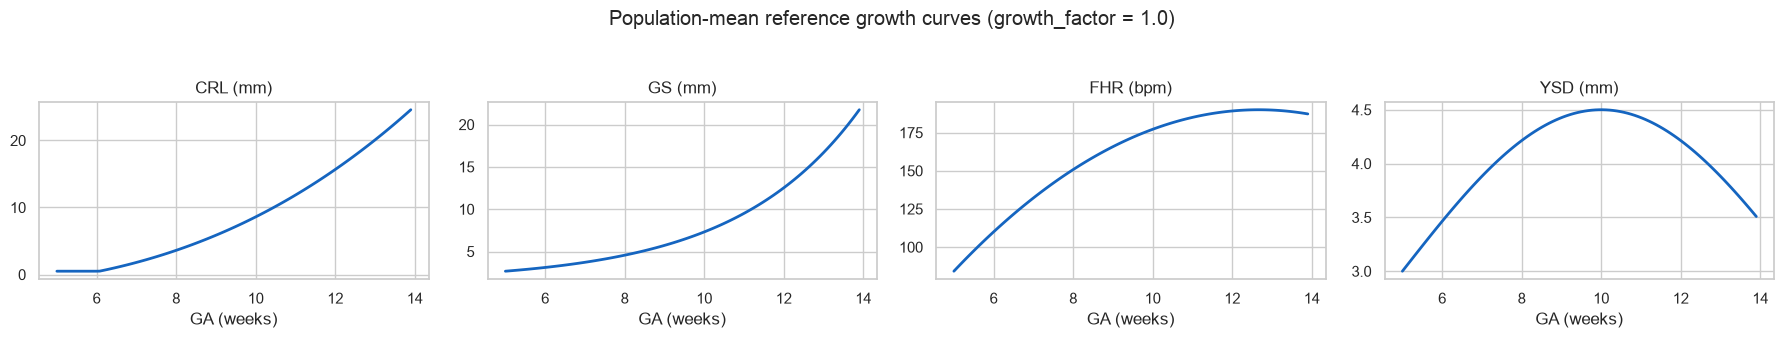

In [4]:
def crl_curve(ga, growth_factor=1.0):
    """CRL (mm) vs GA (weeks). Hadlock (1992) / Robinson-Fleming polynomial fit."""
    g = ga - 5.0  # shift so curve starts near 0 at ~5 weeks
    crl = (-0.6 + 0.84 * g + 0.17 * g**2 + 0.006 * g**3) * growth_factor
    return max(crl, 0.5)


def gs_curve(ga, growth_factor=1.0, placenta_factor=1.0):
    """Gestational sac mean diameter (mm). Exponential growth (Nyberg 1987)."""
    combined = 0.6 * growth_factor + 0.4 * placenta_factor
    gs = (math.exp(0.32 * (ga - 4.5)) + 1.5) * combined
    return max(gs, 1.0)


def fhr_curve(ga, heart_factor=1.0):
    """Fetal heart rate (bpm). Parabolic rise, peak ~wk 9 (Doubilet & Benson 1995)."""
    t = ga - 6.0
    fhr = (110.0 + 24.0 * t - 1.8 * t**2) * heart_factor
    return max(fhr, 0.0)


def ysd_curve(ga, growth_factor=1.0):
    """Yolk sac diameter (mm). Grows wk 5-10 then involutes (Blaas 1995, Cyr 1988)."""
    t = ga - 5.0
    ysd = (3.0 + 1.5 * math.sin(math.pi * t / 10.0)) * growth_factor
    return max(ysd, 0.5)

# quick visual check of the four reference curves
_ga = np.linspace(5.0, GA_MAX, 100)
fig, ax = plt.subplots(1, 4, figsize=(18, 3.2))
for a, (fn, title) in zip(ax, [(crl_curve, "CRL (mm)"), (gs_curve, "GS (mm)"),
                                (fhr_curve, "FHR (bpm)"), (ysd_curve, "YSD (mm)")]):
    a.plot(_ga, [fn(g) for g in _ga], color="#1565C0", lw=2)
    a.set_title(title); a.set_xlabel("GA (weeks)")
fig.suptitle("Population-mean reference growth curves (growth_factor = 1.0)", y=1.05)
plt.tight_layout(); plt.show()

#### 2.3 Patient-level latent biological factors

Draws each patient's hidden biology — `growth`, `heart`, `placenta`, and `noise` factors —
from label-dependent distributions: loss pregnancies are shifted toward slower growth, weaker
heart activity, poorer placentation, and noisier measurements. Crucially the viable and loss
distributions **overlap**, so no single factor separates the classes cleanly and the
prediction task stays non-trivial.

In [5]:
def generate_latent_factors(label):
    """
    Patient-level latent biology. Miscarriage (label=1) patients get shifted
    distributions (slower growth, weaker heart, poorer placentation, more noise).
    Distributions OVERLAP so classification is not trivial.
    """
    if label == 0:  # viable pregnancy
        growth_factor   = np.clip(np.random.normal(1.00, 0.08), 0.75, 1.30)
        heart_factor    = np.clip(np.random.normal(1.00, 0.05), 0.80, 1.20)
        placenta_factor = np.clip(np.random.normal(1.00, 0.07), 0.75, 1.25)
        noise_factor    = np.clip(np.random.normal(1.00, 0.15), 0.50, 1.80)
    else:            # pregnancy loss
        growth_factor   = np.clip(np.random.normal(0.82, 0.12), 0.45, 1.15)
        heart_factor    = np.clip(np.random.normal(0.88, 0.10), 0.55, 1.10)
        placenta_factor = np.clip(np.random.normal(0.80, 0.12), 0.40, 1.10)
        noise_factor    = np.clip(np.random.normal(1.30, 0.25), 0.70, 2.50)
    return growth_factor, heart_factor, placenta_factor, noise_factor

#### 2.4 Correlated maternal features

Generates the seven maternal variables (age, BMI, parity, gravidity, previous loss, conception
mode, singleton) with realistic dependencies rather than independent draws: age and BMI are
correlated, older age raises both miscarriage and IVF probability, prior loss is a strong risk
marker, and the biological constraint gravidity ≥ parity is always enforced. Loss patients are
sampled from higher-risk parameter settings.

In [6]:
def generate_maternal_features(label):
    """
    Age, BMI, parity, gravidity, previous_loss with realistic correlations.
    Copula-like: draw correlated normals, then transform.
      - Older women -> higher miscarriage risk
      - Higher BMI  -> modest increase in risk
      - Previous miscarriage -> strong predictor
      - Gravidity >= parity (always)
      - IVF more common in older / higher-risk patients
    """
    if label == 0:
        age_mu, age_sd   = 29.0, 4.5
        bmi_mu, bmi_sd   = 24.5, 4.0
        prev_loss_prob   = 0.10
        ivf_prob         = 0.08
    else:
        age_mu, age_sd   = 33.5, 5.0
        bmi_mu, bmi_sd   = 26.5, 5.0
        prev_loss_prob   = 0.35
        ivf_prob         = 0.18

    # Correlated age and BMI (rho ~ 0.15)
    rho = 0.15
    z1, z2 = np.random.normal(0, 1, 2)
    z2 = rho * z1 + math.sqrt(1 - rho**2) * z2
    age = np.clip(age_mu + age_sd * z1, 18, 45)
    bmi = np.clip(bmi_mu + bmi_sd * z2, 16, 45)

    # Age modulates previous_loss probability
    age_risk_modifier = max(0, (age - 30) * 0.015)
    prev_loss = int(np.random.rand() < min(prev_loss_prob + age_risk_modifier, 0.65))

    # Gravidity and parity (correlated); higher age -> higher gravidity
    grav_lambda = max(0.8, 0.5 + (age - 25) * 0.08)
    gravidity = max(1, np.random.poisson(grav_lambda))

    # Parity <= gravidity; if previous loss, subtract at least 1 from max
    max_parity = gravidity - prev_loss
    parity = np.random.randint(0, max(1, max_parity + 1))
    gravidity = max(gravidity, parity + prev_loss)  # biological constraint

    # IVF slightly more common in older / previous-loss patients
    ivf_adj = ivf_prob + (0.05 if prev_loss else 0) + max(0, (age - 35) * 0.02)
    conception = "IVF" if np.random.rand() < min(ivf_adj, 0.40) else "Natural"

    return {
        'age': round(age, 1),
        'bmi': round(bmi, 1),
        'parity': int(parity),
        'gravidity': int(gravidity),
        'previous_loss': int(prev_loss),
        'conception': conception,
        'singleton': True,
    }

#### 2.5 Clinically plausible missingness

Blanks out measurements the way a real clinic would: FHR is often unrecorded before ~6.5 weeks
(not yet detectable), CRL can be missing very early, GS is almost always present, and YSD drops
out late once the yolk sac involutes — with loss pregnancies carrying slightly more missingness
overall. This is what forces the models (and the temporal mask) to cope with ragged, incomplete
scan records.

In [7]:
def apply_missingness(scan, ga, label):
    """
    Missingness depends on gestational age and outcome:
      - FHR often missing < 6.5 weeks (not yet detectable)
      - CRL sometimes missing very early (too small to measure)
      - GS rarely missing (almost always visible)
      - YSD sometimes missing late (involuted) or very early
      - Miscarriage pregnancies: slightly higher missingness overall
    """
    base_multiplier = 1.3 if label == 1 else 1.0

    fhr_miss_prob = 0.30 * base_multiplier if ga < 6.5 else (0.05 * base_multiplier if ga < 7.0 else 0.02 * base_multiplier)
    if np.random.rand() < fhr_miss_prob:
        scan['FHR'] = np.nan

    crl_miss_prob = 0.15 * base_multiplier if ga < 6.0 else 0.03 * base_multiplier
    if np.random.rand() < crl_miss_prob:
        scan['CRL'] = np.nan

    gs_miss_prob = 0.02 * base_multiplier
    if np.random.rand() < gs_miss_prob:
        scan['GS'] = np.nan

    if ga > 11.0:
        ysd_miss_prob = 0.35 * base_multiplier
    elif ga < 5.5:
        ysd_miss_prob = 0.20 * base_multiplier
    else:
        ysd_miss_prob = 0.04 * base_multiplier
    if np.random.rand() < ysd_miss_prob:
        scan['YSD'] = np.nan

    return scan

#### 2.6 Longitudinal scan generation (autoregressive)

Assembles each patient's 2–5 scan sequence. Rather than sampling scans independently, every
scan evolves from the **previous** one (a 0.7 curve / 0.3 carry-over blend), so trajectories
are smooth and temporally correlated. Loss pregnancies progressively degrade their growth
factors across scans (up to ~15%) to mimic a failing pregnancy; per-variable measurement noise
is then added, values are clamped to clinical ranges, and missingness is applied.

In [8]:
def generate_scans(pat_id, label, growth_factor, heart_factor,
                   placenta_factor, noise_factor):
    """
    Generate 2-5 longitudinal scans. Each scan evolves from the PREVIOUS
    measurement (autoregressive), not independently. Miscarriage pregnancies
    may stop earlier and show decelerating / declining trajectories.
    """
    if label == 1:
        n_scans = np.random.choice([2, 3, 4, 5], p=[0.35, 0.40, 0.20, 0.05])
    else:
        n_scans = np.random.choice([2, 3, 4, 5], p=[0.30, 0.35, 0.25, 0.10])

    first_ga = np.clip(np.random.normal(GA_FIRST_SCAN_MU, GA_FIRST_SCAN_SD), 5.0, 9.0)

    scans = []
    prev_crl = prev_gs = prev_fhr = prev_ysd = None

    for s_idx in range(n_scans):
        if s_idx == 0:
            ga = round(first_ga, 1)
        else:
            delta = np.clip(np.random.normal(INTER_SCAN_MU, INTER_SCAN_SD), 1.0, 4.0)
            ga = round(scans[-1]['gestational_age_weeks'] + delta, 1)

        if ga > GA_MAX:
            break  # don't generate scans past first trimester

        # For miscarriage: progressively degrade growth factors over scans
        if label == 1:
            progress = s_idx / max(n_scans - 1, 1)  # 0 -> 1
            degrade = 1.0 - 0.15 * progress          # up to 15% degradation
            eff_growth   = growth_factor * degrade
            eff_heart    = heart_factor * degrade
            eff_placenta = placenta_factor * degrade
        else:
            eff_growth, eff_heart, eff_placenta = growth_factor, heart_factor, placenta_factor

        exp_crl = crl_curve(ga, eff_growth)
        exp_gs  = gs_curve(ga, eff_growth, eff_placenta)
        exp_fhr = fhr_curve(ga, eff_heart)
        exp_ysd = ysd_curve(ga, eff_growth)

        # Autoregressive blending (0.7 from curve, 0.3 from previous scan)
        ar_weight = 0.30
        prev_ga = scans[-1]['gestational_age_weeks'] if scans else None

        if prev_crl is not None:
            crl_from_prev = prev_crl + (exp_crl - crl_curve(prev_ga, eff_growth))
            crl_base = (1 - ar_weight) * exp_crl + ar_weight * crl_from_prev
        else:
            crl_base = exp_crl

        if prev_gs is not None:
            gs_from_prev = prev_gs + (exp_gs - gs_curve(prev_ga, eff_growth, eff_placenta))
            gs_base = (1 - ar_weight) * exp_gs + ar_weight * gs_from_prev
        else:
            gs_base = exp_gs

        if prev_fhr is not None:
            fhr_from_prev = prev_fhr + (exp_fhr - fhr_curve(prev_ga, eff_heart))
            fhr_base = (1 - ar_weight) * exp_fhr + ar_weight * fhr_from_prev
        else:
            fhr_base = exp_fhr

        if prev_ysd is not None:
            ysd_from_prev = prev_ysd + (exp_ysd - ysd_curve(prev_ga, eff_growth))
            ysd_base = (1 - ar_weight) * exp_ysd + ar_weight * ysd_from_prev
        else:
            ysd_base = exp_ysd

        # Measurement noise (patient-specific amplitude)
        crl_val = crl_base + np.random.normal(0, MEAS_ERROR['CRL'] * noise_factor)
        gs_val  = gs_base  + np.random.normal(0, MEAS_ERROR['GS']  * noise_factor)
        fhr_val = fhr_base + np.random.normal(0, MEAS_ERROR['FHR'] * noise_factor)
        ysd_val = ysd_base + np.random.normal(0, MEAS_ERROR['YSD'] * noise_factor)

        # Clamp to clinical ranges
        crl_val = round(np.clip(crl_val, *CRL_RANGE), 1)
        gs_val  = round(np.clip(gs_val,  *GS_RANGE),  1)
        fhr_val = round(np.clip(fhr_val, *FHR_RANGE), 1)
        ysd_val = round(np.clip(ysd_val, *YSD_RANGE), 1)

        scan = {'patient_id': pat_id, 'gestational_age_weeks': ga,
                'FHR': fhr_val, 'CRL': crl_val, 'GS': gs_val, 'YSD': ysd_val}
        scan = apply_missingness(scan, ga, label)
        scans.append(scan)

        prev_crl, prev_gs, prev_fhr, prev_ysd = crl_val, gs_val, fhr_val, ysd_val

    return scans

#### 2.7 Run the generation loop

Runs the full generator over all 800 patients — assign a label, draw latent factors and
maternal features, synthesize the scan sequence — and collects everything into two DataFrames
(`patients_df`, `scans_df`). It then imputes any remaining missing ultrasound values by
per-patient longitudinal interpolation with a global-median fallback, so the downstream tensors
are complete.

In [9]:
synthetic_patients, synthetic_scans = [], []

for pid in range(1, N_PATIENTS + 1):
    pat_id = f"P{pid:05d}"
    label = int(np.random.rand() < LOSS_RATE_TARGET)
    gf, hf, pf, nf = generate_latent_factors(label)
    maternal = generate_maternal_features(label)
    synthetic_patients.append({'patient_id': pat_id, **maternal, 'label': label})
    synthetic_scans.extend(generate_scans(pat_id, label, gf, hf, pf, nf))

patients_df = pd.DataFrame(synthetic_patients)
scans_df    = pd.DataFrame(synthetic_scans)

# Imputation: per-patient longitudinal interpolation, then global median fallback
for var in ['FHR', 'CRL', 'GS', 'YSD']:
    scans_df[var] = scans_df.groupby('patient_id')[var].transform(
        lambda x: x.interpolate().bfill().ffill()
    )
    scans_df[var] = scans_df[var].fillna(scans_df[var].median())

patients_df['label'] = patients_df['label'].astype(int)
print(f"Generated {patients_df['patient_id'].nunique()} patients, {len(scans_df)} scans.")
patients_df.head()

Generated 800 patients, 2408 scans.


,patient_id,age,bmi,parity,gravidity,previous_loss,conception,singleton,label
0,P00001,26.4,22.1,1,1,0,IVF,True,0
1,P00002,31.5,22.1,1,1,0,Natural,True,0
2,P00003,36.1,27.4,0,2,0,Natural,True,1
3,P00004,22.6,25.0,0,1,0,Natural,True,0
4,P00005,27.3,26.7,1,1,0,Natural,True,1


#### 2.8 Persist to `data/generated/` (models read from here)

Writes the cohort to disk — `patients.csv`, `scans.csv`, and a `dataset_summary.json` capturing
the seed, cohort counts, loss rate, scans-per-patient stats, and a block of validation checks
(every patient has scans, scan counts in range, no gestational age past the first trimester, no
residual missing values). **This directory is the single source of truth every later layer reads
from.**

In [10]:
patients_csv = GENERATED_DIR / "patients.csv"
scans_csv    = GENERATED_DIR / "scans.csv"
summary_json = GENERATED_DIR / "dataset_summary.json"

patients_df.to_csv(patients_csv, index=False)
scans_df.to_csv(scans_csv, index=False)

scans_per_patient = scans_df.groupby("patient_id").size()
n_loss = int(patients_df["label"].sum())
summary = {
    "seed": SEED,
    "n_patients": int(patients_df["patient_id"].nunique()),
    "n_scans": int(len(scans_df)),
    "n_loss": n_loss,
    "n_live": int(len(patients_df) - n_loss),
    "loss_rate": float(n_loss / len(patients_df)),
    "scans_per_patient": {
        "min": int(scans_per_patient.min()), "max": int(scans_per_patient.max()),
        "mean": float(scans_per_patient.mean()), "median": float(scans_per_patient.median()),
    },
    "columns": {"patients": patients_df.columns.tolist(), "scans": scans_df.columns.tolist()},
    "validation": {
        "all_patients_have_scans": bool(scans_df["patient_id"].nunique() == patients_df["patient_id"].nunique()),
        "min_scans_ok": bool(scans_per_patient.min() >= MIN_SCANS),
        "max_scans_ok": bool(scans_per_patient.max() <= MAX_SCANS),
        "gestational_age_max_ok": bool(scans_df["gestational_age_weeks"].max() <= GA_MAX),
        "no_remaining_missing_us_values": bool(scans_df[["FHR", "CRL", "GS", "YSD"]].isna().sum().sum() == 0),
    },
}
summary_json.write_text(json.dumps(summary, indent=2))
print("Saved:", patients_csv, "|", scans_csv, "|", summary_json)
summary["validation"]

Saved: data/generated/patients.csv | data/generated/scans.csv | data/generated/dataset_summary.json


{'all_patients_have_scans': True,
 'min_scans_ok': True,
 'max_scans_ok': True,
 'gestational_age_max_ok': True,
 'no_remaining_missing_us_values': True}

#### 2.9 Validation & summary statistics

Prints a human-readable audit of the generated cohort: class balance, the scan-count
distribution, and — most importantly — the mean maternal and ultrasound values **split by
outcome**. Loss pregnancies should show older age, higher BMI, more prior loss, and lower growth
measurements, confirming the label-dependent signal is present but not exaggerated.

In [11]:
n_total = patients_df['patient_id'].nunique()
n_loss  = int(patients_df['label'].sum())
print("=" * 60)
print("SYNTHETIC COHORT SUMMARY")
print("=" * 60)
print(f"Total patients        : {n_total}")
print(f"Live births (label=0) : {n_total - n_loss}  ({100*(n_total-n_loss)/n_total:.1f}%)")
print(f"Pregnancy loss (1)    : {n_loss}  ({100*n_loss/n_total:.1f}%)")
print(f"Total scan records    : {len(scans_df)}")
print(f"Scans/patient         : min={scans_per_patient.min()}, max={scans_per_patient.max()}, mean={scans_per_patient.mean():.2f}")

print("\nMaternal features by outcome (mean):")
display(patients_df.groupby('label')[['age', 'bmi', 'parity', 'gravidity', 'previous_loss']].mean().round(2))

print("Ultrasound measurements by outcome (mean):")
merged = scans_df.merge(patients_df[['patient_id', 'label']])
display(merged.groupby('label')[['CRL', 'GS', 'FHR', 'YSD']].mean().round(1))

print("Ultrasound correlation matrix:")
display(scans_df[['FHR', 'CRL', 'GS', 'YSD']].corr().round(3))

SYNTHETIC COHORT SUMMARY
Total patients        : 800
Live births (label=0) : 612  (76.5%)
Pregnancy loss (1)    : 188  (23.5%)
Total scan records    : 2408
Scans/patient         : min=2, max=5, mean=3.01

Maternal features by outcome (mean):


,age,bmi,parity,gravidity,previous_loss
label,,,,,
0,29.10,24.67,0.54,1.33,0.12
1,33.86,26.83,0.57,1.61,0.42


Ultrasound measurements by outcome (mean):


,CRL,GS,FHR,YSD
label,,,,
0,6.5,6.6,154.9,4.1
1,4.9,5.3,129.0,3.2


Ultrasound correlation matrix:


,FHR,CRL,GS,YSD
FHR,1.000,0.701,0.548,0.507
CRL,0.701,1.000,0.798,0.314
GS,0.548,0.798,1.000,0.253
YSD,0.507,0.314,0.253,1.000


#### 2.10 Sanity visualizations

Four diagnostic plots: CRL-vs-GA trajectories by outcome, an FHR-vs-GA scatter, a maternal-age
violin plot per class, and the ultrasound correlation heatmap. The pattern to look for is
**overlap with a shift** — the outcome groups differ on average but are far from separable, which
is exactly the regime that makes the modeling task meaningful.

/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/420706081.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(["Live (0)", "Loss (1)"])


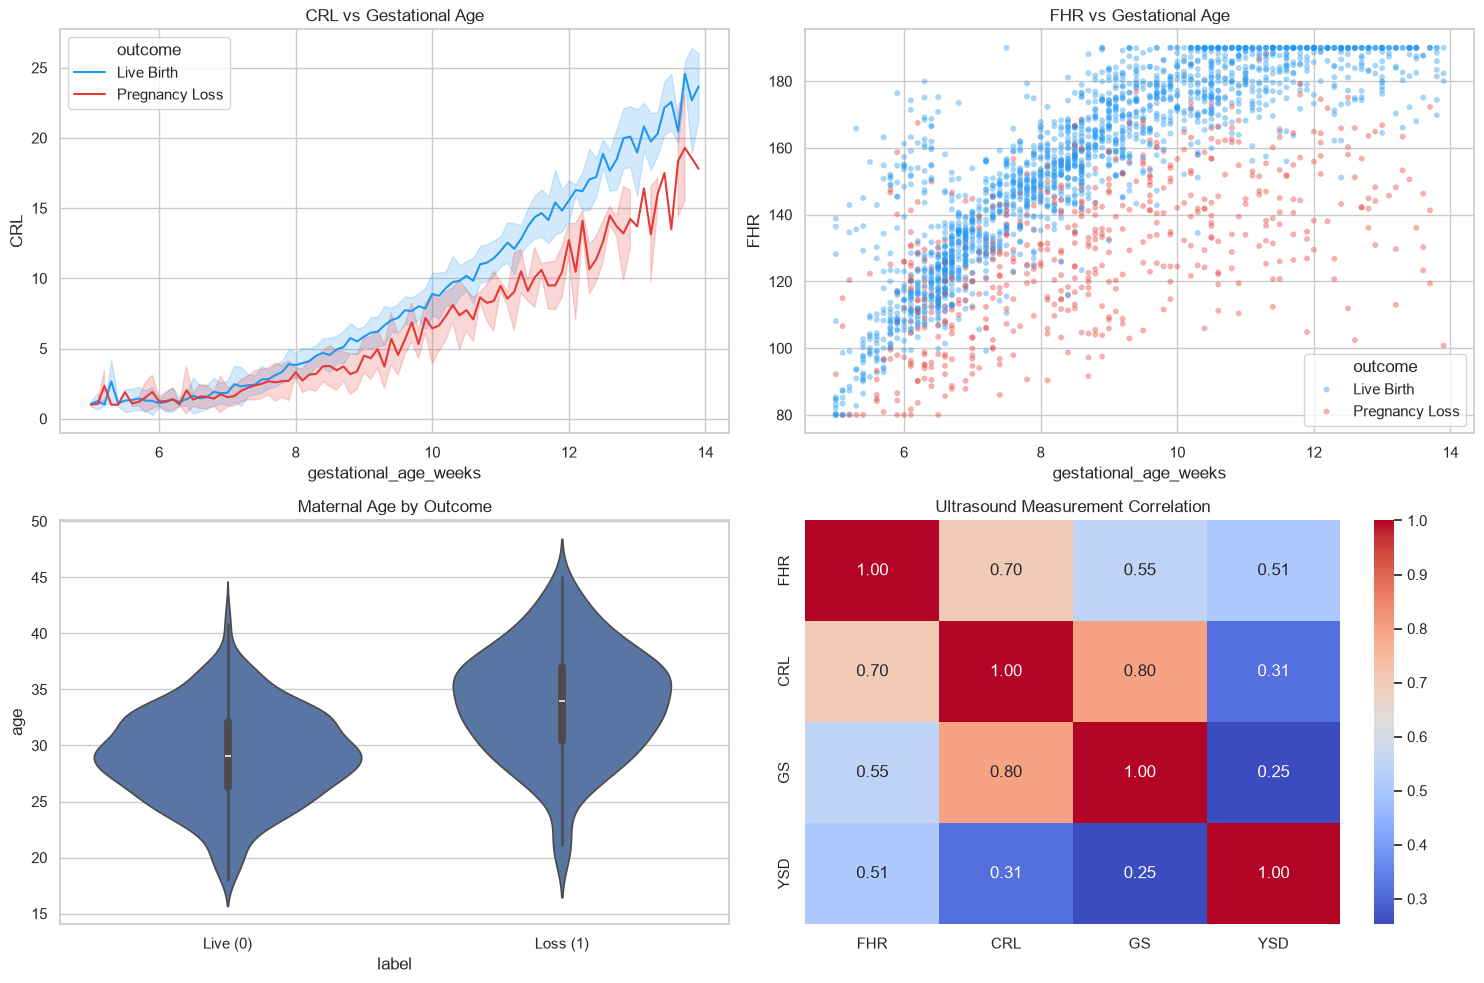

In [12]:
merged = scans_df.merge(patients_df[['patient_id', 'label']])
merged['outcome'] = merged['label'].map({0: 'Live Birth', 1: 'Pregnancy Loss'})
pal = {'Live Birth': '#2196F3', 'Pregnancy Loss': '#E53935'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(ax=axes[0, 0], data=merged, x='gestational_age_weeks', y='CRL',
             hue='outcome', palette=pal, errorbar='sd')
axes[0, 0].set_title("CRL vs Gestational Age")

sns.scatterplot(ax=axes[0, 1], data=merged, x='gestational_age_weeks', y='FHR',
                hue='outcome', palette=pal, alpha=0.4, s=18, edgecolor='none')
axes[0, 1].set_title("FHR vs Gestational Age")

sns.violinplot(ax=axes[1, 0], data=patients_df, x='label', y='age')
axes[1, 0].set_title("Maternal Age by Outcome")
axes[1, 0].set_xticklabels(["Live (0)", "Loss (1)"])

sns.heatmap(ax=axes[1, 1], data=scans_df[['FHR', 'CRL', 'GS', 'YSD']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
axes[1, 1].set_title("Ultrasound Measurement Correlation")

plt.tight_layout(); plt.show()

---
## Layer 2 — Dataset & Graph

The data layer produced two flat CSVs. Models can't read those directly — they need
fixed-shape tensors. This layer turns the cohort into model-ready inputs in two forms:

1. **Temporal batches** (for FETA-Transformer & the ensemble): every patient padded to a
   fixed `T = 5` scans, plus a mask marking which are real.
2. **Knowledge-guided graph** (for PREG-Net): the same numbers re-expressed as nodes
   (clinical variables) and physiologically-motivated edges.

The single most important idea: **one dataset feeds three model signatures.** We build the
temporal tensors once; the graph is *derived* from them on the fly — PREG-Net never reads a
separate file.

Each dataset item yields:

| Tensor | Shape | Meaning |
|--------|-------|---------|
| `temporal_features` | `(T, 4)` | FHR, CRL, GS, YSD per scan |
| `gestational_ages`  | `(T,)`   | actual GA in weeks (for continuous positional encoding) |
| `temporal_mask`     | `(T,)`   | 1 = real scan, 0 = padding |
| `maternal_features` | `(7,)`   | age, bmi, parity, gravidity, previous_loss, conception_ivf, singleton |
| `label`             | scalar   | 0 = viable, 1 = loss |

### 3.0 Imports for the modeling stack
`torch` enters here — this is the first layer that needs it.

In [13]:
from typing import Dict, List, Optional, Tuple

import torch
from torch.utils.data import Dataset, DataLoader

PATIENTS_CSV = str(GENERATED_DIR / "patients.csv")
SCANS_CSV    = str(GENERATED_DIR / "scans.csv")
MAX_SCANS    = 5
print("torch", torch.__version__, "| reading from", PATIENTS_CSV)

torch 2.10.0 | reading from data/generated/patients.csv


### 3.1 `PregnancyDataset`

Turns the CSVs into per-patient tensors. Key behaviors:
- Ultrasound scans are **sorted by gestational age**, then **padded/truncated to `T=5`**.
- Missing US values become 0 (the mask, not the value, tells the model what's real).
- Maternal `conception` is one-hot encoded to `conception_ivf`; `singleton` cast to float.
- Optional `norm_stats` apply z-scoring **only if provided** (we fit them on train only, next).

In [14]:
class PregnancyDataset(Dataset):
    """Per-patient tensors: temporal_features (T,4), gestational_ages (T,),
    temporal_mask (T,), maternal_features (7,), label."""

    US_FEATURES = ['FHR', 'CRL', 'GS', 'YSD']

    def __init__(self, patients_df, scans_df, max_scans=5,
                 us_features=None, norm_stats=None):
        self.max_scans = max_scans
        self.us_features = us_features or self.US_FEATURES
        self.norm_stats = norm_stats

        self.patients = patients_df.copy().reset_index(drop=True)
        # One-hot encode conception method + cast singleton
        self.patients['conception_ivf'] = (
            self.patients['conception'].str.upper() == 'IVF'
        ).astype(float)
        self.patients['singleton'] = self.patients['singleton'].astype(float)

        scans_sorted = scans_df.sort_values(
            ['patient_id', 'gestational_age_weeks']).copy()
        self.scans_by_patient = {
            pid: g for pid, g in scans_sorted.groupby('patient_id')}
        self.patient_ids = self.patients['patient_id'].tolist()

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        pat_row = self.patients[self.patients['patient_id'] == pid].iloc[0]

        scans = self.scans_by_patient.get(pid, pd.DataFrame())
        if len(scans) > 0:
            us_vals = scans[self.us_features].values.astype(np.float32)
            ga_vals = scans['gestational_age_weeks'].values.astype(np.float32)
            n_real = min(len(scans), self.max_scans)
        else:
            us_vals = np.zeros((0, len(self.us_features)), dtype=np.float32)
            ga_vals = np.zeros((0,), dtype=np.float32)
            n_real = 0
        us_vals = np.nan_to_num(us_vals, nan=0.0)

        # Normalize US features if stats provided
        if self.norm_stats is not None:
            for i, feat in enumerate(self.us_features):
                if feat in self.norm_stats:
                    mean, std = self.norm_stats[feat]
                    if std > 1e-8:
                        us_vals[:, i] = (us_vals[:, i] - mean) / std

        # Pad / truncate to max_scans
        temporal_features = np.zeros((self.max_scans, len(self.us_features)), np.float32)
        gestational_ages  = np.zeros(self.max_scans, np.float32)
        temporal_mask     = np.zeros(self.max_scans, np.float32)
        t = min(n_real, self.max_scans)
        if t > 0:
            temporal_features[:t] = us_vals[:t]
            gestational_ages[:t]  = ga_vals[:t]
            temporal_mask[:t]     = 1.0

        # Maternal features (7)
        mat_cols = ['age', 'bmi', 'parity', 'gravidity',
                    'previous_loss', 'conception_ivf', 'singleton']
        maternal = np.array([float(pat_row[c]) for c in mat_cols], np.float32)
        if self.norm_stats is not None:
            for i, feat in enumerate(mat_cols):
                if feat in self.norm_stats:
                    mean, std = self.norm_stats[feat]
                    if std > 1e-8:
                        maternal[i] = (maternal[i] - mean) / std

        return {
            'patient_id': pid,
            'temporal_features': torch.tensor(temporal_features),
            'gestational_ages':  torch.tensor(gestational_ages),
            'temporal_mask':     torch.tensor(temporal_mask),
            'maternal_features': torch.tensor(maternal),
            'label':             torch.tensor(float(pat_row['label'])),
        }

### 3.2 Stratified train / val / test split

Split **within each class** (70/15/15) so the ~23% loss rate is preserved in every split.
Seeded for reproducibility.

In [15]:
def create_splits(patients_df, train_ratio=0.70, val_ratio=0.15,
                  test_ratio=0.15, seed=42):
    """Stratified split by label -> (train_ids, val_ids, test_ids)."""
    rng = np.random.RandomState(seed)
    ids_0 = patients_df[patients_df['label'] == 0]['patient_id'].to_numpy(str).copy()
    ids_1 = patients_df[patients_df['label'] == 1]['patient_id'].to_numpy(str).copy()
    rng.shuffle(ids_0); rng.shuffle(ids_1)

    def _split(ids):
        n = len(ids); n_tr = int(n * train_ratio); n_va = int(n * val_ratio)
        return ids[:n_tr].tolist(), ids[n_tr:n_tr+n_va].tolist(), ids[n_tr+n_va:].tolist()

    tr0, va0, te0 = _split(ids_0)
    tr1, va1, te1 = _split(ids_1)
    return tr0 + tr1, va0 + va1, te0 + te1

### 3.3 Train-only normalization (no leakage)

Z-score stats are computed **from the training split only**, then applied to val/test.
Continuous features (US measurements + age/bmi/parity/gravidity) are normalized; **binary
features (`previous_loss`, `conception_ivf`, `singleton`) are intentionally left as 0/1**.

In [16]:
def compute_norm_stats(patients_df, scans_df, train_ids):
    """Z-score (mean, std) per feature, computed on training patients only."""
    train_scans    = scans_df[scans_df['patient_id'].isin(train_ids)]
    train_patients = patients_df[patients_df['patient_id'].isin(train_ids)]
    stats = {}
    for feat in ['FHR', 'CRL', 'GS', 'YSD']:
        vals = train_scans[feat].dropna()
        stats[feat] = (float(vals.mean()), float(vals.std()))
    for feat in ['age', 'bmi', 'parity', 'gravidity']:
        vals = train_patients[feat].dropna()
        stats[feat] = (float(vals.mean()), float(vals.std()))
    # binary features (previous_loss, conception_ivf, singleton) left un-normalized
    return stats

### 3.4 DataLoaders

A custom collate keeps the string `patient_id`s in a list and stacks the rest into batch
tensors. `get_dataloaders` wires the whole pipeline: **load CSVs → split → fit norm stats on
train → build train/val/test loaders.**

In [17]:
def _collate_fn(batch):
    """Custom collate that keeps patient_id strings out of the tensor stack."""
    return {
        'patient_id':        [b['patient_id'] for b in batch],
        'temporal_features': torch.stack([b['temporal_features'] for b in batch]),
        'gestational_ages':  torch.stack([b['gestational_ages']  for b in batch]),
        'temporal_mask':     torch.stack([b['temporal_mask']     for b in batch]),
        'maternal_features': torch.stack([b['maternal_features'] for b in batch]),
        'label':             torch.stack([b['label']             for b in batch]),
    }


def get_dataloaders(patients_csv, scans_csv, batch_size=32, max_scans=5,
                    seed=42, num_workers=0):
    """Load CSVs -> stratified split -> train-only normalization -> DataLoaders."""
    patients_df = pd.read_csv(patients_csv)
    scans_df    = pd.read_csv(scans_csv)

    train_ids, val_ids, test_ids = create_splits(patients_df, seed=seed)
    norm_stats = compute_norm_stats(patients_df, scans_df, train_ids)

    loaders = {}
    for name, ids in [('train', train_ids), ('val', val_ids), ('test', test_ids)]:
        ds = PregnancyDataset(
            patients_df[patients_df['patient_id'].isin(ids)],
            scans_df[scans_df['patient_id'].isin(ids)],
            max_scans=max_scans, norm_stats=norm_stats)
        loaders[name] = DataLoader(
            ds, batch_size=batch_size, shuffle=(name == 'train'),
            num_workers=num_workers, collate_fn=_collate_fn, drop_last=False)

    print(f"Splits — train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}")
    return loaders, norm_stats

### 3.5 Build the loaders and inspect one batch

Calls `get_dataloaders` to run the whole pipeline end-to-end, then prints three checks: the
per-split loss rate (should match across train/val/test, confirming stratification held), the
train-only normalization statistics, and the tensor shapes of a single batch — the concrete
`temporal_features` / `gestational_ages` / `temporal_mask` / `maternal_features` / `label` shapes
every model consumes.

In [18]:
loaders, norm_stats = get_dataloaders(
    PATIENTS_CSV, SCANS_CSV, batch_size=32, max_scans=MAX_SCANS, seed=42)

# Verify stratification: loss rate per split
for name in ['train', 'val', 'test']:
    labels = torch.cat([b['label'] for b in loaders[name]])
    print(f"  {name:5} — n={len(labels):4d}, loss rate={labels.mean().item():.3f}")

print("\nNormalization stats (mean, std) — fit on train only:")
for k, v in norm_stats.items():
    print(f"  {k:16} ({v[0]:8.2f}, {v[1]:7.2f})")

# Pull one training batch and show tensor shapes
batch = next(iter(loaders['train']))
print("\nOne batch:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k:18} {tuple(v.shape)}   dtype={v.dtype}")
    else:
        print(f"  {k:18} list[str] len={len(v)}  e.g. {v[0]}")

Splits — train: 559, val: 119, test: 122
  train — n= 559, loss rate=0.234
  val   — n= 119, loss rate=0.235
  test  — n= 122, loss rate=0.238

Normalization stats (mean, std) — fit on train only:
  FHR              (  149.24,   28.35)
  CRL              (    6.24,    5.41)
  GS               (    6.39,    4.18)
  YSD              (    3.91,    0.74)
  age              (   30.28,    4.76)
  bmi              (   25.28,    4.25)
  parity           (    0.55,    0.73)
  gravidity        (    1.40,    0.82)

One batch:
  patient_id         list[str] len=32  e.g. P00130
  temporal_features  (32, 5, 4)   dtype=torch.float32
  gestational_ages   (32, 5)   dtype=torch.float32
  temporal_mask      (32, 5)   dtype=torch.float32
  maternal_features  (32, 7)   dtype=torch.float32
  label              (32,)   dtype=torch.float32


### 3.6 Knowledge-guided graph construction (for PREG-Net)

PREG-Net reasons over a graph whose **structure encodes physiology**, not learned correlations.
For `T=5` scans there are `5×4 + 7 = 27` nodes:
- **Temporal nodes** — FHR, CRL, GS, YSD at each of the 5 time steps.
- **Maternal nodes** — the 7 static features.

Three edge families (all hard-coded, shared across patients):
- **Physiological** (within a time step): FHR↔CRL, YSD↔GS, CRL↔GS, FHR↔YSD.
- **Temporal** (same variable across consecutive scans): FHR(t)↔FHR(t+1), …
- **Maternal→US**: age/BMI/prev-loss → all US; gravidity/parity → FHR,CRL; conception → FHR,CRL,GS.

> The paper's Table lists FHR→CRL, YSD→GS, Age→FHR/CRL, BMI→All, Prior-loss→All as *examples*;
> the code adds a few more physiological edges (CRL↔GS, FHR↔YSD) and maternal mappings. These are
> defensible elaborations, but worth naming explicitly in the manuscript.

In [19]:
# ── Node type constants ───────────────────────────────────────────────────────
NODE_FHR, NODE_CRL, NODE_GS, NODE_YSD = 0, 1, 2, 3            # temporal US types
NODE_AGE, NODE_BMI, NODE_PARITY, NODE_GRAVIDITY = 4, 5, 6, 7  # maternal types
NODE_PREV_LOSS, NODE_CONCEPTION, NODE_SINGLETON = 8, 9, 10

N_US_TYPES = 4
N_MATERNAL_TYPES = 7
N_NODE_TYPES = N_US_TYPES + N_MATERNAL_TYPES  # 11

EDGE_PHYSIOLOGICAL, EDGE_TEMPORAL, EDGE_MATERNAL_TO_US = 0, 1, 2

# Physiological edges (within a time step), bidirectional
INTRA_TIME_EDGES = [
    (NODE_FHR, NODE_CRL), (NODE_CRL, NODE_FHR),
    (NODE_YSD, NODE_GS),  (NODE_GS,  NODE_YSD),
    (NODE_CRL, NODE_GS),  (NODE_GS,  NODE_CRL),
    (NODE_FHR, NODE_YSD), (NODE_YSD, NODE_FHR),
]

# Maternal -> US targets
MATERNAL_TO_US_MAPPING = {
    NODE_AGE:        [NODE_FHR, NODE_CRL, NODE_GS, NODE_YSD],
    NODE_BMI:        [NODE_FHR, NODE_CRL, NODE_GS, NODE_YSD],
    NODE_PREV_LOSS:  [NODE_FHR, NODE_CRL, NODE_GS, NODE_YSD],
    NODE_GRAVIDITY:  [NODE_FHR, NODE_CRL],
    NODE_PARITY:     [NODE_FHR, NODE_CRL],
    NODE_CONCEPTION: [NODE_FHR, NODE_CRL, NODE_GS],
}


def build_knowledge_graph(n_time_steps=5):
    """Return (edge_index (2,E), edge_type (E,)) for the shared knowledge graph."""
    n_temporal = n_time_steps * N_US_TYPES
    src, dst, etype = [], [], []

    # 1. Intra-time-step physiological edges
    for t in range(n_time_steps):
        off = t * N_US_TYPES
        for s, d in INTRA_TIME_EDGES:
            src.append(off + s); dst.append(off + d); etype.append(EDGE_PHYSIOLOGICAL)

    # 2. Temporal edges (same variable across consecutive steps, both directions)
    for var in range(N_US_TYPES):
        for t in range(n_time_steps - 1):
            a = t * N_US_TYPES + var
            b = (t + 1) * N_US_TYPES + var
            src += [a, b]; dst += [b, a]; etype += [EDGE_TEMPORAL, EDGE_TEMPORAL]

    # 3. Maternal -> US edges (at every time step)
    for mat_type, targets in MATERNAL_TO_US_MAPPING.items():
        mat_idx = n_temporal + (mat_type - N_US_TYPES)
        for t in range(n_time_steps):
            for us in targets:
                src.append(mat_idx); dst.append(t * N_US_TYPES + us)
                etype.append(EDGE_MATERNAL_TO_US)

    return (torch.tensor([src, dst], dtype=torch.long),
            torch.tensor(etype, dtype=torch.long))

### 3.7 `PatientGraphBuilder` — derive per-patient graphs from a temporal batch

The graph *structure* is shared; only the **node values** and **node mask** change per patient.
Temporal node values come from `temporal_features`; maternal node values from `maternal_features`.
A padded scan's four US nodes are masked out so they can't send or receive messages.

In [20]:
class PatientGraphBuilder:
    """Convert a FETA-style batch dict into PREG-Net graph tensors."""

    def __init__(self, max_scans=5):
        self.max_scans = max_scans
        self.n_temporal = max_scans * N_US_TYPES
        self.n_maternal = N_MATERNAL_TYPES
        self.n_nodes = self.n_temporal + self.n_maternal

        self.edge_index, self.edge_type = build_knowledge_graph(max_scans)

        node_types = []
        for _ in range(max_scans):
            node_types += [NODE_FHR, NODE_CRL, NODE_GS, NODE_YSD]
        node_types += [NODE_AGE, NODE_BMI, NODE_PARITY, NODE_GRAVIDITY,
                       NODE_PREV_LOSS, NODE_CONCEPTION, NODE_SINGLETON]
        self.node_types = torch.tensor(node_types, dtype=torch.long)

    def batch_to_graph(self, batch):
        B = batch['temporal_features'].shape[0]
        T = self.max_scans

        temporal_flat = batch['temporal_features'].reshape(B, T * N_US_TYPES)  # (B, T*4)
        maternal = batch['maternal_features']                                  # (B, 7)
        node_features = torch.cat([temporal_flat, maternal], dim=1).unsqueeze(-1)  # (B, N, 1)

        # Node mask: US nodes valid only where a scan exists; maternal always valid
        temporal_mask = batch['temporal_mask']  # (B, T)
        temporal_node_mask = temporal_mask.unsqueeze(-1).expand(
            B, T, N_US_TYPES).reshape(B, T * N_US_TYPES)
        maternal_mask = torch.ones(B, self.n_maternal, device=temporal_mask.device)
        node_mask = torch.cat([temporal_node_mask, maternal_mask], dim=1)

        return {
            'node_features': node_features,
            'edge_index':    self.edge_index,
            'edge_type':     self.edge_type,
            'node_types':    self.node_types,
            'node_mask':     node_mask,
        }

### 3.8 Build graphs for a batch and inspect the structure

Runs `PatientGraphBuilder` on the batch from 3.5 and reports the derived graph: 27 nodes, the
edge count broken down by family (physiological / temporal / maternal→US), the per-patient tensor
shapes, and how many nodes are valid for the first patient (real scans × 4 + 7 maternal). This
confirms the graph is built correctly, on the fly, from the same temporal tensors.

In [21]:
graph_builder = PatientGraphBuilder(max_scans=MAX_SCANS)
graph = graph_builder.batch_to_graph(batch)

E = graph['edge_index'].shape[1]
etype = graph['edge_type']
print(f"Graph: N={graph_builder.n_nodes} nodes, E={E} edges (shared across the batch)\n")
print("Edges by type:")
for name, code_ in [('physiological', EDGE_PHYSIOLOGICAL),
                    ('temporal', EDGE_TEMPORAL),
                    ('maternal->US', EDGE_MATERNAL_TO_US)]:
    print(f"  {name:14} {int((etype == code_).sum())}")

print("\nPer-patient graph tensors:")
for k, v in graph.items():
    print(f"  {k:14} {tuple(v.shape)}")

# For the first patient, how many valid (unmasked) nodes?
nm = graph['node_mask'][0]
print(f"\nPatient {batch['patient_id'][0]}: {int(nm.sum())}/{len(nm)} nodes valid "
      f"({int(batch['temporal_mask'][0].sum())} real scans + 7 maternal)")

Graph: N=27 nodes, E=167 edges (shared across the batch)

Edges by type:
  physiological  40
  temporal       32
  maternal->US   95

Per-patient graph tensors:
  node_features  (32, 27, 1)
  edge_index     (2, 167)
  edge_type      (167,)
  node_types     (27,)
  node_mask      (32, 27)

Patient P00130: 23/27 nodes valid (4 real scans + 7 maternal)


### 3.9 Visualize the knowledge graph

Draws the hard-coded knowledge graph so its structure is legible at a glance: the 5×4 grid of
temporal ultrasound nodes, the seven maternal nodes down the left, and the three edge families
colour-coded (physiological within a time step, temporal across time, maternal→US). This is the
fixed scaffold PREG-Net reasons over — identical for every patient; only the node values and mask
change.

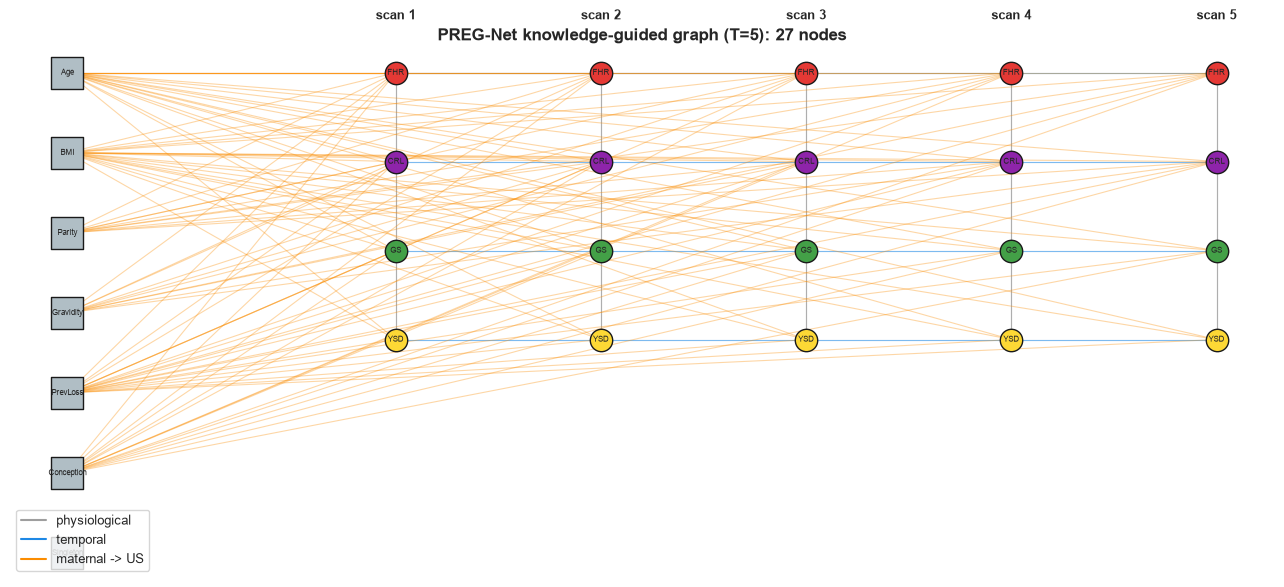

In [22]:
# Node layout: temporal nodes in a grid (x=time step, y=variable), maternal in a left column
edge_index = graph['edge_index'].numpy()
edge_type  = graph['edge_type'].numpy()

var_names = ['FHR', 'CRL', 'GS', 'YSD']
mat_names = ['Age', 'BMI', 'Parity', 'Gravidity', 'PrevLoss', 'Conception', 'Singleton']
pos = {}
for t in range(MAX_SCANS):
    for var in range(N_US_TYPES):
        pos[t * N_US_TYPES + var] = (t, 3 - var)      # FHR on top
for j in range(N_MATERNAL_TYPES):
    pos[MAX_SCANS * N_US_TYPES + j] = (-1.6, 3.0 - j * 0.9)

edge_colors = {EDGE_PHYSIOLOGICAL: '#9E9E9E', EDGE_TEMPORAL: '#1E88E5',
               EDGE_MATERNAL_TO_US: '#FB8C00'}
var_colors = ['#E53935', '#8E24AA', '#43A047', '#FDD835']

fig, ax = plt.subplots(figsize=(13, 6))
for e in range(edge_index.shape[1]):
    s, d = edge_index[0, e], edge_index[1, e]
    x0, y0 = pos[s]; x1, y1 = pos[d]
    ax.plot([x0, x1], [y0, y1], color=edge_colors[edge_type[e]], alpha=0.35, lw=0.8, zorder=1)

for node, (x, y) in pos.items():
    if node < MAX_SCANS * N_US_TYPES:
        var = node % N_US_TYPES
        ax.scatter(x, y, s=260, color=var_colors[var], edgecolor='k', zorder=2)
        ax.text(x, y, var_names[var], ha='center', va='center', fontsize=6, zorder=3)
    else:
        j = node - MAX_SCANS * N_US_TYPES
        ax.scatter(x, y, s=520, marker='s', color='#B0BEC5', edgecolor='k', zorder=2)
        ax.text(x, y, mat_names[j], ha='center', va='center', fontsize=6, zorder=3)

for t in range(MAX_SCANS):
    ax.text(t, 3.6, f"scan {t+1}", ha='center', fontsize=9, fontweight='bold')

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], color=edge_colors[EDGE_PHYSIOLOGICAL], label='physiological'),
          Line2D([0], [0], color=edge_colors[EDGE_TEMPORAL], label='temporal'),
          Line2D([0], [0], color=edge_colors[EDGE_MATERNAL_TO_US], label='maternal -> US')]
ax.legend(handles=legend, loc='lower left', fontsize=9)
ax.set_title("PREG-Net knowledge-guided graph (T=5): 27 nodes", fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

---
## Layer 3 — Models

Three architectures, all pure PyTorch (no `torch_geometric`):

1. **FETA-Transformer** — learns temporal patterns over the longitudinal scans.
2. **PREG-Net** — reasons over the knowledge graph with graph attention.
3. **Ensemble** — late fusion of the two.

Every model returns **raw logits** (apply `sigmoid` for probabilities) **plus an attention
dict** for explainability — the attention keys are a contract the later layers depend on, so
we keep them stable.

### 4.0 Neural-net imports

Brings in `torch.nn` / `torch.nn.functional`, re-seeds torch for reproducible initialization, and
defines a small `count_params` helper used throughout this layer to report each model's size.

In [23]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

### 4.1 FETA-Transformer

Four innovations over a vanilla Transformer, each its own module:

| Module | What it does |
|--------|--------------|
| `ContinuousPositionalEncoding` | positional signal from **actual gestational week**, not sequence index — so wk 6→7 differs from 9→10 |
| `ModalityProjection` | a separate learnable projection per measurement type (FHR/CRL/GS/YSD) |
| `AttentionPooling` | a learnable query pools time steps → discovers which weeks matter |
| `MaternalCrossAttention` | maternal features query the temporal representation |

Flow: modality projections → +positional encoding → Transformer encoder → attention pooling →
maternal cross-attention → classifier.

#### 4.1a Continuous positional encoding

The first FETA component. A vanilla Transformer positions tokens by integer index; here the
sinusoidal encoding is a function of the **actual gestational age in weeks**, so the model knows a
scan at week 6 versus week 9 is genuinely further apart than two adjacent sequence positions — and
it handles the irregular spacing between real scans.

In [24]:
class ContinuousPositionalEncoding(nn.Module):
    """PE(t,2i)=sin(t / theta^(2i/d)), PE(t,2i+1)=cos(...), with t = gestational age (weeks)."""
    def __init__(self, d_model, theta=10000.0):
        super().__init__()
        self.d_model = d_model
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32)
                             * (-math.log(theta) / d_model))
        self.register_buffer('div_term', div_term)

    def forward(self, gestational_ages):            # (B, T) -> (B, T, d_model)
        B, T = gestational_ages.shape
        ga = gestational_ages.unsqueeze(-1)                          # (B, T, 1)
        angles = ga * self.div_term.unsqueeze(0).unsqueeze(0)        # (B, T, d/2)
        pe = torch.zeros(B, T, self.d_model, device=gestational_ages.device)
        pe[:, :, 0::2] = torch.sin(angles)
        pe[:, :, 1::2] = torch.cos(angles)
        return pe

#### 4.1b Modality-specific projections

Gives each measurement type its own `Linear(1 → d_model)` projection and sums them, so FHR, CRL,
GS, and YSD are embedded through separate learned transforms rather than treated as interchangeable
numbers. This lets the model learn per-variable scale and meaning before any attention happens.

In [25]:
class ModalityProjection(nn.Module):
    """Each of FHR/CRL/GS/YSD gets its own Linear(1, d_model); projections are summed."""
    def __init__(self, n_modalities=4, d_model=64):
        super().__init__()
        self.projections = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_modalities)])

    def forward(self, x):                            # (B, T, n_mod) -> (B, T, d_model)
        h = torch.zeros(x.shape[0], x.shape[1], self.projections[0].out_features,
                        device=x.device, dtype=x.dtype)
        for i, proj in enumerate(self.projections):
            h = h + proj(x[:, :, i:i+1])
        return h

#### 4.1c Attention pooling & maternal cross-attention

Two modules. `AttentionPooling` uses a learnable query to collapse the variable-length scan
sequence into a single vector, weighting time steps by relevance (and exposing those weights for
explainability). `MaternalCrossAttention` then lets the maternal features **query** that pooled
temporal representation — fusing static risk factors with the scan trajectory, with a residual
connection and layer norm.

In [26]:
class AttentionPooling(nn.Module):
    """Learnable query pools time steps: alpha_t = softmax(w^T tanh(Wh_t)); z = sum alpha_t h_t."""
    def __init__(self, d_model):
        super().__init__()
        self.query = nn.Parameter(torch.randn(d_model))
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, h, mask=None):                 # h: (B, T, d)
        h_proj = torch.tanh(self.proj(h))
        scores = torch.einsum('btd,d->bt', h_proj, self.query)      # (B, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)                         # (B, T)
        z = torch.einsum('bt,btd->bd', weights, h)                  # (B, d)
        return z, weights


class MaternalCrossAttention(nn.Module):
    """Maternal features (query) attend to the pooled temporal representation (key/value)."""
    def __init__(self, d_model, n_maternal=7, n_heads=2, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(n_maternal, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, temporal_repr, maternal):      # (B, d), (B, n_maternal)
        B = temporal_repr.shape[0]
        kv = temporal_repr.unsqueeze(1)                             # (B, 1, d)
        Q = self.W_q(maternal).unsqueeze(1)
        K = self.W_k(kv); V = self.W_v(kv)
        Q = Q.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        K = K.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        V = V.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = self.dropout(F.softmax(scores, dim=-1))
        ctx = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, -1)
        out = self.layer_norm(self.W_o(ctx) + temporal_repr)       # residual
        return out, scores.squeeze(-1).squeeze(-1)                  # (B, d), (B, n_heads)

#### 4.1d The full FETA-Transformer

Wires the pieces into the complete model: modality projection → add continuous positional encoding
→ Transformer encoder (with the padding mask) → attention pooling → maternal cross-attention → MLP
classifier. It returns **raw logits plus the attention dict** (`temporal_pooling_weights`,
`cross_attention_weights`) — the interpretability contract Layer 6 depends on.

In [27]:
class FETATransformer(nn.Module):
    """Modality proj -> +continuous PE -> Transformer encoder -> attention pool ->
    maternal cross-attn -> classifier. Returns (logits, attention_dict)."""
    def __init__(self, d_model=64, n_heads=4, n_layers=2, d_ff=128, dropout=0.2,
                 n_us_features=4, n_maternal=7):
        super().__init__()
        self.d_model = d_model
        self.modality_proj = ModalityProjection(n_us_features, d_model)
        self.pos_encoder = ContinuousPositionalEncoding(d_model)
        self.input_norm = nn.LayerNorm(d_model)
        self.input_dropout = nn.Dropout(dropout)
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                dim_feedforward=d_ff, dropout=dropout, activation='gelu',
                batch_first=True, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.attn_pool = AttentionPooling(d_model)
        self.maternal_cross_attn = MaternalCrossAttention(
            d_model, n_maternal=n_maternal, n_heads=min(2, n_heads), dropout=dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, temporal_features, gestational_ages, temporal_mask, maternal_features):
        h = self.modality_proj(temporal_features)
        h = h + self.pos_encoder(gestational_ages)
        h = self.input_dropout(self.input_norm(h))
        h = self.transformer_encoder(h, src_key_padding_mask=(temporal_mask == 0))
        z, pool_w = self.attn_pool(h, mask=temporal_mask)
        z, cross_w = self.maternal_cross_attn(z, maternal_features)
        logits = self.classifier(z)
        return logits, {'temporal_pooling_weights': pool_w, 'cross_attention_weights': cross_w}

#### 4.1e Forward-pass check (random init)

Runs one forward pass on the real batch to verify the wiring: prints the parameter count and
confirms the logits and both attention tensors come out with the expected shapes. Nothing is
trained yet — this only proves the shapes line up.

In [28]:
feta = FETATransformer().eval()
with torch.no_grad():
    logits, attn = feta(batch['temporal_features'], batch['gestational_ages'],
                        batch['temporal_mask'], batch['maternal_features'])
print("FETA-Transformer  params:", f"{count_params(feta):,}")
print("  logits:", tuple(logits.shape))
for k, v in attn.items():
    print(f"  attn['{k}']: {tuple(v.shape)}")

FETA-Transformer  params: 87,169
  logits: (32, 1)
  attn['temporal_pooling_weights']: (32, 5)
  attn['cross_attention_weights']: (32, 2)


/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/528397646.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)


### 4.2 PREG-Net

A **Graph Attention Network** hand-written in PyTorch. Each layer computes patient-specific
edge weights `alpha_vu = softmax(LeakyReLU(a^T[Wh_v || Wh_u]))` and message-passes with
`scatter_add`. A gated readout aggregates nodes into a graph embedding, exposing **node
importance** and **per-layer edge attention** for explainability.

#### 4.2a GAT layer (pure PyTorch)

A multi-head Graph Attention layer written from scratch — no `torch_geometric`. It computes
patient-specific edge weights, `α = softmax(LeakyReLU(aᵀ[Wh_v ∥ Wh_u]))`, masks out padded nodes,
and message-passes with `scatter_add_` and a numerically stable sparse softmax. It returns the
updated node features **and** the per-edge attention weights for later inspection.

In [29]:
class GATLayer(nn.Module):
    """Dense multi-head GAT for small graphs. Returns (out, edge_attn)."""
    def __init__(self, in_dim, out_dim, n_heads=4, dropout=0.2,
                 leaky_relu_slope=0.2, concat=True):
        super().__init__()
        self.in_dim, self.out_dim, self.n_heads, self.concat = in_dim, out_dim, n_heads, concat
        self.W = nn.Parameter(torch.empty(n_heads, in_dim, out_dim))
        self.a_src = nn.Parameter(torch.empty(n_heads, out_dim, 1))
        self.a_dst = nn.Parameter(torch.empty(n_heads, out_dim, 1))
        self.leaky_relu = nn.LeakyReLU(leaky_relu_slope)
        self.dropout = nn.Dropout(dropout)
        self.bias = nn.Parameter(torch.zeros(n_heads * out_dim if concat else out_dim))
        nn.init.xavier_uniform_(self.W)
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, edge_index, node_mask=None):
        B, N, _ = x.shape
        H, E = self.n_heads, edge_index.shape[1]
        src, dst = edge_index[0], edge_index[1]
        Wh = torch.einsum('bni,hio->bhno', x, self.W)               # (B, H, N, out)
        score_src = torch.einsum('bhno,hoi->bhni', Wh, self.a_src).squeeze(-1)
        score_dst = torch.einsum('bhno,hoi->bhni', Wh, self.a_dst).squeeze(-1)
        edge_scores = self.leaky_relu(score_src[:, :, src] + score_dst[:, :, dst])  # (B,H,E)
        if node_mask is not None:
            edge_scores = edge_scores.masked_fill(
                node_mask[:, src].unsqueeze(1) == 0, -1e9)
        edge_attn = self.dropout(self._sparse_softmax(edge_scores, dst, N))
        messages = Wh[:, :, src, :] * edge_attn.unsqueeze(-1)       # (B, H, E, out)
        out = torch.zeros(B, H, N, self.out_dim, device=x.device, dtype=x.dtype)
        dst_exp = dst.view(1, 1, E, 1).expand(B, H, E, self.out_dim)
        out.scatter_add_(2, dst_exp, messages)
        out = (out.permute(0, 2, 1, 3).reshape(B, N, H * self.out_dim)
               if self.concat else out.mean(dim=1))
        return out + self.bias, edge_attn

    @staticmethod
    def _sparse_softmax(scores, indices, n_nodes):
        B, H, E = scores.shape
        idx = indices.view(1, 1, E).expand(B, H, E)
        max_vals = torch.full((B, H, n_nodes), -1e9, device=scores.device)
        max_vals.scatter_reduce_(2, idx, scores, reduce='amax')
        exp_scores = torch.exp(scores - max_vals.gather(2, idx))
        sum_exp = torch.zeros(B, H, n_nodes, device=scores.device)
        sum_exp.scatter_add_(2, idx, exp_scores)
        return exp_scores / (sum_exp.gather(2, idx) + 1e-10)

#### 4.2b Readout & the full PREG-Net

`GraphReadout` aggregates nodes into a single graph embedding with a learned gate, exposing each
node's importance. `PREGNet` then assembles the model: node-type embedding plus value projection →
stacked residual GAT layers → gated readout → MLP classifier. Like FETA, it returns raw logits and
an attention dict (`node_importance`, per-layer `edge_attention`).

In [30]:
class GraphReadout(nn.Module):
    """Attention-weighted node aggregation: beta_v = softmax(MLP(h_v)); z = sum beta_v h_v."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
                                  nn.Linear(hidden_dim, 1))

    def forward(self, h, node_mask=None):
        scores = self.gate(h).squeeze(-1)
        if node_mask is not None:
            scores = scores.masked_fill(node_mask == 0, -1e9)
        node_imp = F.softmax(scores, dim=-1)
        return torch.einsum('bn,bnd->bd', node_imp, h), node_imp


class PREGNet(nn.Module):
    """Type-embedding + value-proj -> stacked GAT layers (residual) -> gated readout ->
    classifier. Returns (logits, {'node_importance', 'edge_attention'})."""
    def __init__(self, hidden_dim=64, n_gat_layers=2, n_heads=4, dropout=0.2,
                 n_node_types=11, leaky_relu_slope=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.type_embedding = nn.Embedding(n_node_types, hidden_dim)
        self.value_proj = nn.Linear(1, hidden_dim)
        self.gat_layers = nn.ModuleList()
        self.gat_norms = nn.ModuleList()
        for _ in range(n_gat_layers):
            self.gat_layers.append(GATLayer(hidden_dim, hidden_dim // n_heads,
                    n_heads=n_heads, dropout=dropout,
                    leaky_relu_slope=leaky_relu_slope, concat=True))
            self.gat_norms.append(nn.LayerNorm(hidden_dim))
        self.gat_dropout = nn.Dropout(dropout)
        self.readout = GraphReadout(hidden_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, node_features, edge_index, node_types, node_mask=None):
        B = node_features.shape[0]
        type_emb = self.type_embedding(node_types)
        if type_emb.dim() == 2:
            type_emb = type_emb.unsqueeze(0).expand(B, -1, -1)
        h = type_emb + self.value_proj(node_features)
        if node_mask is not None:
            h = h * node_mask.unsqueeze(-1)
        edge_attentions = []
        for gat, norm in zip(self.gat_layers, self.gat_norms):
            residual = h
            h, edge_attn = gat(h, edge_index, node_mask)
            h = self.gat_dropout(F.elu(h))
            h = norm(h + residual)
            if node_mask is not None:
                h = h * node_mask.unsqueeze(-1)
            edge_attentions.append(edge_attn)
        z, node_imp = self.readout(h, node_mask)
        logits = self.classifier(z)
        return logits, {'node_importance': node_imp, 'edge_attention': edge_attentions}

#### 4.2c Forward-pass check (random init)

One forward pass on the graph batch from 3.8 to confirm PREG-Net's wiring: parameter count, logit
shape, and the shapes of the node-importance and per-layer edge-attention tensors. Untrained — a
shapes-only sanity check.

In [31]:
preg = PREGNet().eval()
with torch.no_grad():
    logits, attn = preg(graph['node_features'], graph['edge_index'],
                        graph['node_types'], graph['node_mask'])
print("PREG-Net          params:", f"{count_params(preg):,}")
print("  logits:", tuple(logits.shape))
print("  attn['node_importance']:", tuple(attn['node_importance'].shape))
print("  attn['edge_attention']:", len(attn['edge_attention']), "layers, each",
      tuple(attn['edge_attention'][0].shape))

PREG-Net          params: 16,130
  logits: (32, 1)
  attn['node_importance']: (32, 27)
  attn['edge_attention']: 2 layers, each (32, 4, 167)


### 4.3 Ensemble (late fusion)

Runs both sub-models and fuses their logits — either a plain average (default) or a learned
`Linear(2, 1)` initialized to equal weighting. Returns a dict with the fused logits, each
model's logits, both attention dicts, and the effective fusion weights.

In [32]:
class EnsemblePredictor(nn.Module):
    """Late-fusion of FETA-Transformer + PREG-Net (average or learned)."""
    def __init__(self, feta_kwargs=None, preg_kwargs=None, learned_fusion=False):
        super().__init__()
        self.feta = FETATransformer(**(feta_kwargs or {}))
        self.preg = PREGNet(**(preg_kwargs or {}))
        self.learned_fusion = learned_fusion
        if learned_fusion:
            self.fusion_layer = nn.Linear(2, 1, bias=True)
            nn.init.constant_(self.fusion_layer.weight, 0.5)
            nn.init.constant_(self.fusion_layer.bias, 0.0)

    def forward(self, temporal_features, gestational_ages, temporal_mask, maternal_features,
                node_features, edge_index, node_types, node_mask=None):
        feta_logits, feta_attn = self.feta(
            temporal_features, gestational_ages, temporal_mask, maternal_features)
        preg_logits, preg_attn = self.preg(
            node_features, edge_index, node_types, node_mask)
        if self.learned_fusion:
            combined = self.fusion_layer(torch.cat([feta_logits, preg_logits], dim=-1))
            fusion_w = self.fusion_layer.weight.detach().squeeze()
        else:
            combined = (feta_logits + preg_logits) / 2.0
            fusion_w = torch.tensor([0.5, 0.5], device=feta_logits.device)
        return {'logits': combined, 'feta_logits': feta_logits, 'preg_logits': preg_logits,
                'feta_attention': feta_attn, 'preg_attention': preg_attn,
                'fusion_weights': fusion_w}

#### 4.3a Forward-pass check + model size summary

Runs the ensemble on both input sets at once and prints its output dict (fused logits, each
sub-model's logits, the fusion weights), followed by a side-by-side parameter count for all three
models. The final line confirms `sigmoid(logits)` sits near 0.5 — the expected output of an
untrained network, before Layer 4 fits it.

In [33]:
ensemble = EnsemblePredictor(learned_fusion=False).eval()
with torch.no_grad():
    out = ensemble(batch['temporal_features'], batch['gestational_ages'],
                   batch['temporal_mask'], batch['maternal_features'],
                   graph['node_features'], graph['edge_index'],
                   graph['node_types'], graph['node_mask'])
print("Ensemble          params:", f"{count_params(ensemble):,}")
print("  output keys:", list(out.keys()))
print("  fused logits:", tuple(out['logits'].shape),
      "| feta:", tuple(out['feta_logits'].shape),
      "| preg:", tuple(out['preg_logits'].shape))
print("  fusion weights:", out['fusion_weights'].tolist())

print("\nModel sizes:")
for name, m in [('FETA-Transformer', feta), ('PREG-Net', preg), ('Ensemble', ensemble)]:
    print(f"  {name:18} {count_params(m):>10,} params")

# Sanity: probabilities are in [0,1]
probs = torch.sigmoid(out['logits'])
print(f"\nSigmoid(logits) range: [{probs.min():.3f}, {probs.max():.3f}]  (untrained -> near 0.5)")

Ensemble          params: 103,299
  output keys: ['logits', 'feta_logits', 'preg_logits', 'feta_attention', 'preg_attention', 'fusion_weights']
  fused logits: (32, 1) | feta: (32, 1) | preg: (32, 1)
  fusion weights: [0.5, 0.5]

Model sizes:
  FETA-Transformer       87,169 params
  PREG-Net               16,130 params
  Ensemble              103,299 params

Sigmoid(logits) range: [0.279, 0.417]  (untrained -> near 0.5)


/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/528397646.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)


---
## Layer 4 — Training

One training loop fits all three model families. The trick is `collate_mode`:

| `collate_mode` | Batch is unpacked into… | Model |
|----------------|-------------------------|-------|
| `"feta"`     | temporal + maternal tensors | FETA-Transformer |
| `"preg"`     | graph tensors (built on the fly) | PREG-Net |
| `"ensemble"` | **both** | Ensemble |

Common ingredients: **weighted BCE** (`pos_weight = n_neg/n_pos`) for the ~23% imbalance,
AdamW + cosine warm restarts, gradient clipping, **early-stopping & checkpointing on validation
AUROC** (higher is better). Models output raw logits; we sigmoid for probabilities.

### 5.1 Metrics

`compute_all_metrics` returns AUROC, AUPRC, accuracy, sensitivity, specificity, F1, precision,
recall from `(y_true, y_prob)`. AUROC/AUPRC/specificity are `nan` if a batch has a single class
(the bootstrap/CV code later skips such degenerate cases).

In [34]:
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)

def compute_all_metrics(y_true, y_prob, threshold=0.5):
    """Binary-classification metric bundle from probabilities."""
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_pred = (y_prob >= threshold).astype(np.int64)

    if len(np.unique(y_true)) < 2:          # single class -> AUROC/AUPRC undefined
        auroc = auprc = specificity = float("nan")
    else:
        auroc = float(roc_auc_score(y_true, y_prob))
        auprc = float(average_precision_score(y_true, y_prob))
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    return {
        "auroc": auroc, "auprc": auprc,
        "accuracy":    float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": specificity,
        "f1":          float(f1_score(y_true, y_pred, zero_division=0)),
        "precision":   float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":      float(recall_score(y_true, y_pred, zero_division=0)),
    }

### 5.2 Class weights, early stopping, device

Two training utilities. `compute_class_weights` returns `pos_weight = n_neg / n_pos` to up-weight
the minority (loss) class in the BCE loss. `EarlyStopping` tracks the monitored metric and halts
once it stops improving for `patience` epochs — configured with `mode="max"` here because we
checkpoint on **validation AUROC**, where higher is better.

In [35]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import time

def compute_class_weights(labels):
    """pos_weight = n_negative / n_positive for BCEWithLogitsLoss."""
    labels = np.asarray(labels, dtype=np.float64)
    n_pos = labels.sum(); n_neg = len(labels) - n_pos
    return float(n_neg / n_pos) if n_pos > 0 else 1.0


class EarlyStopping:
    """Stop when the monitored metric fails to improve for `patience` epochs (mode='max')."""
    def __init__(self, patience=10, min_delta=0.0, mode="max"):
        self.patience, self.min_delta, self.mode = patience, min_delta, mode
        self.counter = 0; self.best_score = None; self.should_stop = False

    def _improved(self, cur):
        if self.best_score is None:
            return True
        return (cur > self.best_score + self.min_delta) if self.mode == "max" \
               else (cur < self.best_score - self.min_delta)

    def __call__(self, value):
        if self._improved(value):
            self.best_score = value; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

### 5.3 The unified `Trainer`

`_unpack_batch` is where `collate_mode` does its work — it assembles exactly the kwargs each
model's `forward` expects (and builds graph tensors for `preg`/`ensemble`). The loop tolerates
both tuple outputs (FETA, PREG return `(logits, attn)`) and dict outputs (Ensemble).

In [36]:
class Trainer:
    """Train/validate loop with weighted BCE, cosine warm restarts, early-stop &
    checkpoint on val AUROC. collate_mode selects how batches feed the model."""

    def __init__(self, model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4,
                 pos_weight=1.0, patience=10, checkpoint_dir="checkpoints",
                 device=None, t_0=10, t_mult=2, collate_mode="ensemble",
                 graph_builder=None, max_scans=5, log_every=10):
        self.device = device or torch.device("cpu")
        self.model = model.to(self.device)
        self.train_loader, self.val_loader = train_loader, val_loader
        assert collate_mode in {"feta", "preg", "ensemble"}
        self.collate_mode = collate_mode
        self.graph_builder = graph_builder or PatientGraphBuilder(max_scans=max_scans)
        self.log_every = log_every

        self.criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], device=self.device))
        self.optimizer = AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.scheduler = CosineAnnealingWarmRestarts(self.optimizer, T_0=t_0, T_mult=t_mult)
        self.early_stopping = EarlyStopping(patience=patience, mode="max")

        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.best_auroc = 0.0
        self.history = []

    def _unpack_batch(self, batch):
        batch = {k: (v.to(self.device) if torch.is_tensor(v) else v)
                 for k, v in batch.items()}
        labels = batch.pop("label")
        batch.pop("patient_id", None)

        if self.collate_mode == "feta":
            return {k: batch[k] for k in ("temporal_features", "gestational_ages",
                                          "temporal_mask", "maternal_features")}, labels

        graph = self.graph_builder.batch_to_graph(batch)
        graph = {k: (v.to(self.device) if torch.is_tensor(v) else v) for k, v in graph.items()}
        graph_inputs = {k: graph[k] for k in ("node_features", "edge_index",
                                              "node_types", "node_mask")}
        if self.collate_mode == "preg":
            return graph_inputs, labels
        return {**{k: batch[k] for k in ("temporal_features", "gestational_ages",
                                         "temporal_mask", "maternal_features")},
                **graph_inputs}, labels

    @staticmethod
    def _logits(outputs):
        if isinstance(outputs, dict):  return outputs["logits"]
        if isinstance(outputs, tuple): return outputs[0]
        return outputs

    def train_epoch(self):
        self.model.train()
        logits_all, labels_all, tot, nb = [], [], 0.0, 0
        for batch in self.train_loader:
            inputs, labels = self._unpack_batch(batch)
            self.optimizer.zero_grad()
            logits = self._logits(self.model(**inputs))
            loss = self.criterion(logits.squeeze(-1), labels.float())
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            tot += loss.item(); nb += 1
            logits_all.append(logits.detach().cpu()); labels_all.append(labels.detach().cpu())
        self.scheduler.step()
        yp = torch.sigmoid(torch.cat(logits_all).squeeze(-1)).numpy()
        yt = torch.cat(labels_all).numpy()
        m = compute_all_metrics(yt, yp)
        return {"loss": tot / max(nb, 1), "auroc": m["auroc"], "auprc": m["auprc"]}

    @torch.no_grad()
    def validate_epoch(self):
        self.model.eval()
        logits_all, labels_all, tot, nb = [], [], 0.0, 0
        for batch in self.val_loader:
            inputs, labels = self._unpack_batch(batch)
            logits = self._logits(self.model(**inputs))
            tot += self.criterion(logits.squeeze(-1), labels.float()).item(); nb += 1
            logits_all.append(logits.cpu()); labels_all.append(labels.cpu())
        yp = torch.sigmoid(torch.cat(logits_all).squeeze(-1)).numpy()
        yt = torch.cat(labels_all).numpy()
        m = compute_all_metrics(yt, yp); m["loss"] = tot / max(nb, 1)
        return m

    def _save_checkpoint(self, epoch, auroc):
        torch.save({"epoch": epoch, "model_state_dict": self.model.state_dict(),
                    "best_auroc": auroc}, self.checkpoint_dir / "best_model.pt")

    def load_best(self):
        ckpt = torch.load(self.checkpoint_dir / "best_model.pt",
                          map_location=self.device, weights_only=True)
        self.model.load_state_dict(ckpt["model_state_dict"])
        return ckpt

    def fit(self, n_epochs=80):
        for epoch in range(1, n_epochs + 1):
            t0 = time.time()
            tr = self.train_epoch(); va = self.validate_epoch()
            self.history.append({"epoch": epoch, "time_s": time.time() - t0,
                                 "train_loss": tr["loss"], "train_auroc": tr["auroc"],
                                 "val_loss": va["loss"], "val_auroc": va["auroc"],
                                 "val_auprc": va["auprc"]})
            if va["auroc"] > self.best_auroc:
                self.best_auroc = va["auroc"]; self._save_checkpoint(epoch, va["auroc"])
            if self.log_every and (epoch % self.log_every == 0 or epoch == 1):
                print(f"    epoch {epoch:3d} | train_loss={tr['loss']:.4f} "
                      f"val_loss={va['loss']:.4f} | val_AUROC={va['auroc']:.4f} "
                      f"val_AUPRC={va['auprc']:.4f}")
            if self.early_stopping(va["auroc"]):
                print(f"    early stop @ epoch {epoch} (best val AUROC={self.best_auroc:.4f})")
                break
        return self.history

### 5.4 Training configuration

CPU by default (reproducible, widest Mac compatibility). `EPOCHS`/`PATIENCE` are the knobs;
`pos_weight` is derived from the **training** label distribution.

In [37]:
from pathlib import Path
RESULTS_DIR = Path("results")
DEVICE   = torch.device("cpu")
EPOCHS   = 80
PATIENCE = 15

train_labels = torch.cat([b['label'] for b in loaders['train']]).numpy()
POS_WEIGHT = compute_class_weights(train_labels)
print(f"Train loss rate = {train_labels.mean():.3f}  ->  pos_weight = {POS_WEIGHT:.3f}")
print(f"Device = {DEVICE} | epochs = {EPOCHS} | patience = {PATIENCE}")

Train loss rate = 0.234  ->  pos_weight = 3.267
Device = cpu | epochs = 80 | patience = 15


### 5.5 Train all four models

A small helper builds a `Trainer`, fits, restores the best checkpoint, and saves history.
We train FETA-Transformer, PREG-Net, the average-fusion Ensemble, and the learned-fusion
Ensemble. Each checkpoints to `results/<name>/checkpoints/best_model.pt`.

In [38]:
trained_models, histories = {}, {}

def train_model(key, model, collate_mode, epochs=EPOCHS):
    print(f"\n=== Training {key}  (collate_mode={collate_mode}) ===")
    trainer = Trainer(model, loaders['train'], loaders['val'],
                      pos_weight=POS_WEIGHT, patience=PATIENCE, collate_mode=collate_mode,
                      device=DEVICE, checkpoint_dir=RESULTS_DIR / key / "checkpoints")
    t0 = time.time()
    hist = trainer.fit(epochs)
    trainer.load_best()  # restore best-val-AUROC weights
    hist_df = pd.DataFrame(hist)
    (RESULTS_DIR / key).mkdir(parents=True, exist_ok=True)
    hist_df.to_csv(RESULTS_DIR / key / "history.csv", index=False)
    print(f"  done in {time.time()-t0:.1f}s — best val AUROC = {trainer.best_auroc:.4f}")
    trained_models[key] = trainer.model
    histories[key] = hist_df
    return trainer

In [39]:
_ = train_model("feta_transformer", FETATransformer(), "feta")


=== Training feta_transformer  (collate_mode=feta) ===


/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/528397646.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)


    epoch   1 | train_loss=0.8461 val_loss=0.4946 | val_AUROC=0.9325 val_AUPRC=0.8594
    epoch  10 | train_loss=0.2036 val_loss=0.5970 | val_AUROC=0.9655 val_AUPRC=0.9171
    epoch  20 | train_loss=0.2058 val_loss=0.5090 | val_AUROC=0.9631 val_AUPRC=0.9267
    epoch  30 | train_loss=0.1757 val_loss=0.5534 | val_AUROC=0.9670 val_AUPRC=0.9379
    early stop @ epoch 32 (best val AUROC=0.9710)
  done in 11.4s — best val AUROC = 0.9710


In [40]:
_ = train_model("preg_net", PREGNet(), "preg")


=== Training preg_net  (collate_mode=preg) ===
    epoch   1 | train_loss=1.0184 val_loss=0.8372 | val_AUROC=0.9152 val_AUPRC=0.7962
    epoch  10 | train_loss=0.4438 val_loss=0.4768 | val_AUROC=0.9384 val_AUPRC=0.8691
    epoch  20 | train_loss=0.3751 val_loss=0.4014 | val_AUROC=0.9576 val_AUPRC=0.9027
    epoch  30 | train_loss=0.3688 val_loss=0.4385 | val_AUROC=0.9600 val_AUPRC=0.9109
    epoch  40 | train_loss=0.2496 val_loss=0.5728 | val_AUROC=0.9478 val_AUPRC=0.8874
    early stop @ epoch 49 (best val AUROC=0.9647)
  done in 18.7s — best val AUROC = 0.9647


In [41]:
_ = train_model("ensemble", EnsemblePredictor(learned_fusion=False), "ensemble")


=== Training ensemble  (collate_mode=ensemble) ===


/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/528397646.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)


    epoch   1 | train_loss=0.8141 val_loss=0.6860 | val_AUROC=0.9199 val_AUPRC=0.8245
    epoch  10 | train_loss=0.2490 val_loss=0.5296 | val_AUROC=0.9596 val_AUPRC=0.9256
    epoch  20 | train_loss=0.1479 val_loss=0.6527 | val_AUROC=0.9537 val_AUPRC=0.9333
    epoch  30 | train_loss=0.1456 val_loss=0.5201 | val_AUROC=0.9592 val_AUPRC=0.9464
    early stop @ epoch 30 (best val AUROC=0.9702)
  done in 14.6s — best val AUROC = 0.9702


In [42]:
_ = train_model("ensemble_learned", EnsemblePredictor(learned_fusion=True), "ensemble")


=== Training ensemble_learned  (collate_mode=ensemble) ===


/var/folders/vy/d63833md0j10sxw4rp6rm7r00000gn/T/ipykernel_91343/528397646.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=n_layers)


    epoch   1 | train_loss=0.7472 val_loss=0.6025 | val_AUROC=0.9160 val_AUPRC=0.8327
    epoch  10 | train_loss=0.2511 val_loss=0.5003 | val_AUROC=0.9482 val_AUPRC=0.9190
    epoch  20 | train_loss=0.1610 val_loss=0.5052 | val_AUROC=0.9655 val_AUPRC=0.9477
    epoch  30 | train_loss=0.1572 val_loss=0.4438 | val_AUROC=0.9678 val_AUPRC=0.9495
    epoch  40 | train_loss=0.1172 val_loss=0.5738 | val_AUROC=0.9635 val_AUPRC=0.9367
    early stop @ epoch 47 (best val AUROC=0.9714)
  done in 22.9s — best val AUROC = 0.9714


### 5.6 Training curves

Overlays the four models' validation AUROC and validation loss across epochs, then prints each
model's best AUROC and the epoch it occurred. Useful for spotting overfitting (loss turning up
while AUROC plateaus) and confirming early stopping caught the right checkpoint.

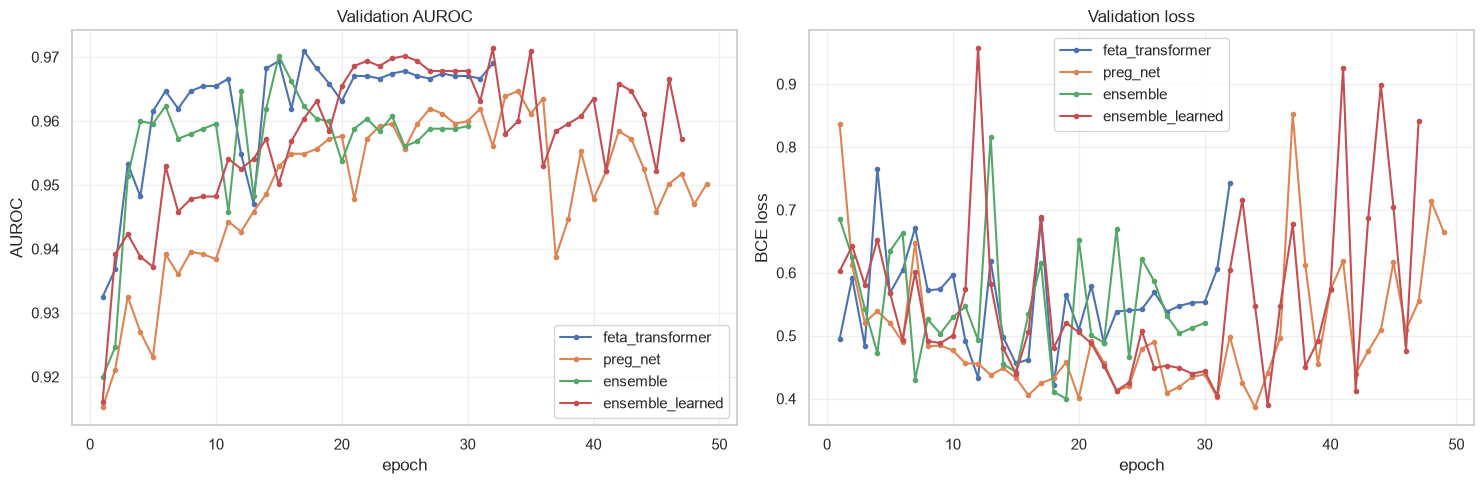

Best validation AUROC per model:
  feta_transformer   0.9710  (epoch 17)
  preg_net           0.9647  (epoch 34)
  ensemble           0.9702  (epoch 15)
  ensemble_learned   0.9714  (epoch 32)


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for key, h in histories.items():
    axes[0].plot(h['epoch'], h['val_auroc'], marker='.', label=key)
    axes[1].plot(h['epoch'], h['val_loss'],  marker='.', label=key)
axes[0].set_title("Validation AUROC"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("AUROC")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation loss");  axes[1].set_xlabel("epoch"); axes[1].set_ylabel("BCE loss")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Best validation AUROC per model:")
for key, h in histories.items():
    print(f"  {key:18} {h['val_auroc'].max():.4f}  (epoch {int(h['val_auroc'].idxmax())+1})")

---
## Layer 5 — Evaluation & Comparison

The models have never seen the **test** split. Now we score every model on it with the full
metric set, add tabular baselines for context, and lay them side by side with ROC/PR curves,
confusion matrices, and bootstrap confidence intervals.

The metric of record is **AUROC** (threshold-free); F1/sensitivity/specificity use a 0.5 cut.

### 6.1 Score the deep models on the test split

`deep_predict` replays the `collate_mode` logic to get probabilities and true labels for any of
our models over a loader. We keep `patient_id`s so predictions can be traced later.

In [44]:
COLLATE = {'feta_transformer': 'feta', 'preg_net': 'preg',
           'ensemble': 'ensemble', 'ensemble_learned': 'ensemble'}

@torch.no_grad()
def deep_predict(model, loader, collate_mode, device=DEVICE):
    model.eval()
    ys, ps, pids = [], [], []
    for batch in loader:
        labels = batch['label']; pids += list(batch['patient_id'])
        b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        if collate_mode == 'feta':
            inp = {k: b[k] for k in ('temporal_features', 'gestational_ages',
                                     'temporal_mask', 'maternal_features')}
        else:
            g = graph_builder.batch_to_graph(b)
            g = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in g.items()}
            gi = {k: g[k] for k in ('node_features', 'edge_index', 'node_types', 'node_mask')}
            inp = gi if collate_mode == 'preg' else {
                **{k: b[k] for k in ('temporal_features', 'gestational_ages',
                                     'temporal_mask', 'maternal_features')}, **gi}
        out = model(**inp)
        logits = out['logits'] if isinstance(out, dict) else (out[0] if isinstance(out, tuple) else out)
        ps.append(torch.sigmoid(logits.squeeze(-1)).cpu().numpy())
        ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps), pids

# Collect test predictions for every trained model
test_preds = {}          # key -> (y_true, y_prob)
for key, model in trained_models.items():
    yt, yp, pids = deep_predict(model, loaders['test'], COLLATE[key])
    test_preds[key] = (yt, yp)
    print(f"  {key:18} test n={len(yt)}  test AUROC={compute_all_metrics(yt, yp)['auroc']:.4f}")

  feta_transformer   test n=122  test AUROC=0.9941
  preg_net           test n=122  test AUROC=0.9885
  ensemble           test n=122  test AUROC=0.9985
  ensemble_learned   test n=122  test AUROC=0.9985


### 6.2 Tabular baselines

The paper compares the deep models against classic tabular learners. We collapse each patient's
longitudinal scans into fixed features — per-variable **mean / last / slope-over-GA** plus
**scan count** and the 7 maternal features — then fit standard classifiers on the **train** split
and score them on **test**. (`previous_loss`, `conception`, `singleton` enter as-is.)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Recover the exact split patient-id lists (same seed as the loaders)
_pat = pd.read_csv(PATIENTS_CSV); _scan = pd.read_csv(SCANS_CSV)
train_ids, val_ids, test_ids = create_splits(_pat, seed=42)

def build_tabular_features(ids):
    pats = _pat[_pat['patient_id'].isin(ids)].copy()
    pats['conception_ivf'] = (pats['conception'].str.upper() == 'IVF').astype(float)
    pats['singleton'] = pats['singleton'].astype(float)
    rows = []
    for _, p in pats.iterrows():
        s = _scan[_scan['patient_id'] == p['patient_id']].sort_values('gestational_age_weeks')
        ga = s['gestational_age_weeks'].values
        feat = {'scan_count': len(s)}
        for var in ['FHR', 'CRL', 'GS', 'YSD']:
            v = s[var].values
            feat[f'{var}_mean'] = float(np.mean(v)) if len(v) else 0.0
            feat[f'{var}_last'] = float(v[-1]) if len(v) else 0.0
            feat[f'{var}_slope'] = float(np.polyfit(ga, v, 1)[0]) if len(v) >= 2 else 0.0
        for m in ['age', 'bmi', 'parity', 'gravidity', 'previous_loss',
                  'conception_ivf', 'singleton']:
            feat[m] = float(p[m])
        rows.append(feat)
    X = pd.DataFrame(rows, index=pats['patient_id'])
    y = pats['label'].to_numpy()
    return X, y

X_train, y_train = build_tabular_features(train_ids)
X_test,  y_test  = build_tabular_features(test_ids)
print(f"Tabular features: {X_train.shape[1]} cols | train {X_train.shape[0]} | test {X_test.shape[0]}")

baselines = {
    'logistic_regression':   make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')),
    'random_forest':         RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'hist_gradient_boosting':HistGradientBoostingClassifier(random_state=42),
    'mlp':                   make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
}
try:
    from xgboost import XGBClassifier
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    baselines['xgboost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                         scale_pos_weight=spw, eval_metric='logloss', random_state=42)
    print("xgboost available -> included")
except Exception as e:
    print("xgboost not available -> skipped:", e)

for name, clf in baselines.items():
    clf.fit(X_train, y_train)
    yp = clf.predict_proba(X_test)[:, 1]
    test_preds[name] = (y_test, yp)
    print(f"  {name:22} test AUROC={compute_all_metrics(y_test, yp)['auroc']:.4f}")

Tabular features: 20 cols | train 559 | test 122
xgboost available -> included
  logistic_regression    test AUROC=0.9870
  random_forest          test AUROC=0.9911
  hist_gradient_boosting test AUROC=0.9863
  mlp                    test AUROC=0.9867
  xgboost                test AUROC=0.9874


### 6.3 Model comparison table

Full metric set for every model on the held-out test split, sorted by AUROC. Saved to
`results/model_comparison.csv` / `.md`.

In [46]:
METRIC_COLS = ['auroc', 'auprc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'precision']
rows = []
for key, (yt, yp) in test_preds.items():
    m = compute_all_metrics(yt, yp)
    rows.append({'model': key, **{c: m[c] for c in METRIC_COLS}})
comparison = (pd.DataFrame(rows).set_index('model')
              .sort_values('auroc', ascending=False).round(4))

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(RESULTS_DIR / "model_comparison.csv")
(RESULTS_DIR / "model_comparison.md").write_text(comparison.to_markdown())
print("Saved results/model_comparison.csv / .md\n")
comparison

Saved results/model_comparison.csv / .md



,auroc,auprc,accuracy,sensitivity,specificity,f1,precision
model,,,,,,,
ensemble,0.9985,0.9954,0.9754,1.0000,0.9677,0.9508,0.9062
ensemble_learned,0.9985,0.9958,0.9754,0.9655,0.9785,0.9492,0.9333
feta_transformer,0.9941,0.9824,0.9508,0.8276,0.9892,0.8889,0.9600
random_forest,0.9911,0.9702,0.9426,0.9310,0.9462,0.8852,0.8438
preg_net,0.9885,0.9746,0.9426,0.9655,0.9355,0.8889,0.8235
xgboost,0.9874,0.9609,0.9426,0.9310,0.9462,0.8852,0.8438
logistic_regression,0.9870,0.9521,0.9508,0.9310,0.9570,0.9000,0.8710
mlp,0.9867,0.9593,0.9344,0.8966,0.9462,0.8667,0.8387
hist_gradient_boosting,0.9863,0.9593,0.9426,0.8621,0.9677,0.8772,0.8929


### 6.4 ROC and precision-recall curves

Plots ROC and precision-recall curves for every model on the test split — the four research models
drawn boldly, the tabular baselines thin for context — with AUROC / AUPRC in each legend. The PR
panel's dashed prevalence line marks the no-skill baseline, the more honest reference on this
imbalanced (~22% positive) cohort.

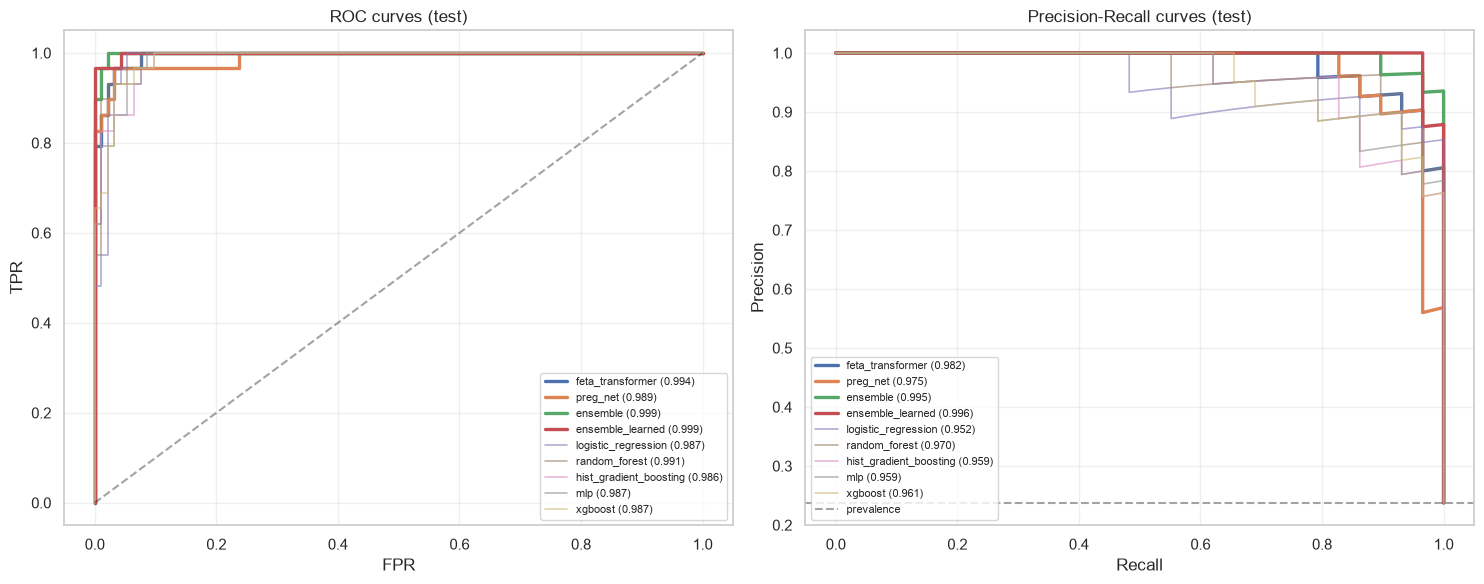

In [47]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Highlight the research models; baselines drawn thin
research = ['feta_transformer', 'preg_net', 'ensemble', 'ensemble_learned']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for key, (yt, yp) in test_preds.items():
    is_res = key in research
    lw, alpha = (2.4, 1.0) if is_res else (1.2, 0.6)
    auroc = compute_all_metrics(yt, yp)['auroc']
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=lw, alpha=alpha, label=f"{key} ({auroc:.3f})")
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = compute_all_metrics(yt, yp)['auprc']
    axes[1].plot(rec, prec, lw=lw, alpha=alpha, label=f"{key} ({ap:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title("ROC curves (test)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(alpha=0.3)
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4, label='prevalence')
axes[1].set_title("Precision-Recall curves (test)"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc='lower left'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6.5 Confusion matrices (research models, threshold 0.5)

Confusion matrices for the four research models at a 0.5 decision threshold, showing the concrete
trade-off behind the headline metrics — how many losses are caught (true positives) versus missed
(false negatives), and how many viable pregnancies are wrongly flagged. Unlike the threshold-free
AUROC, these numbers move with the chosen cut-off.

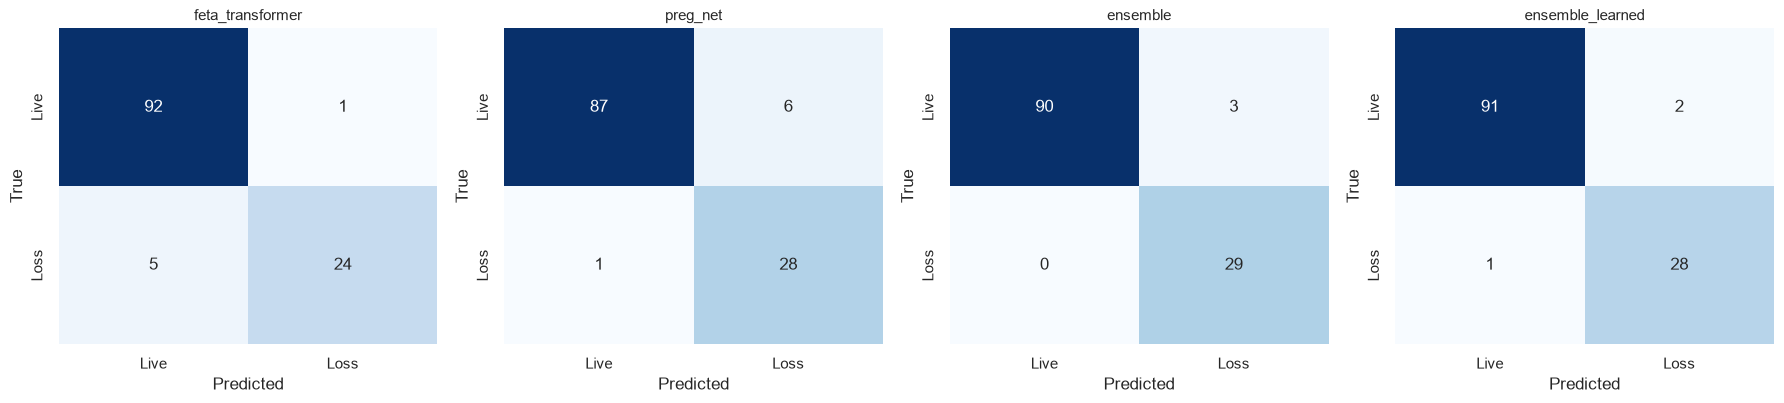

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, key in zip(axes, research):
    yt, yp = test_preds[key]
    cm = confusion_matrix(yt, (yp >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Live', 'Loss'], yticklabels=['Live', 'Loss'])
    ax.set_title(key, fontsize=11); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

### 6.6 Bootstrap 95% confidence intervals (test AUROC)

Percentile bootstrap over the test set — resamples with replacement, skips any degenerate
single-class resample. Gives an uncertainty band around each point estimate.

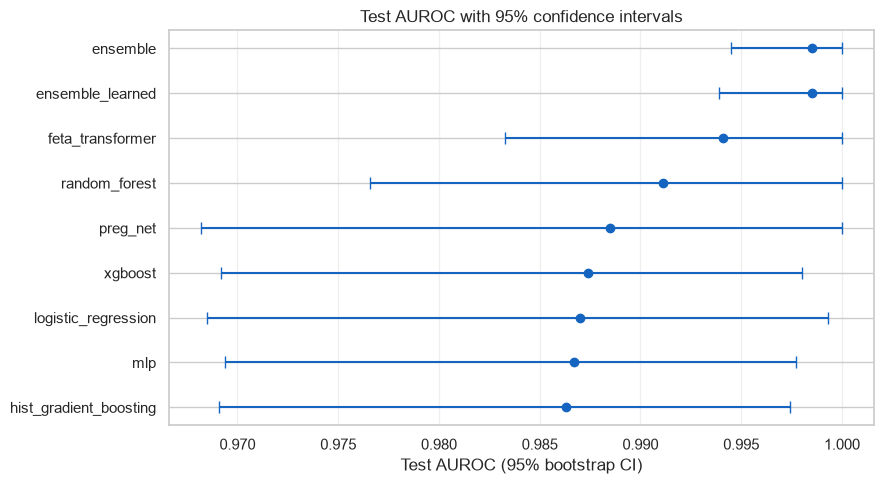

,auroc,ci_low,ci_high
model,,,
ensemble,0.9985,0.9945,1.0000
ensemble_learned,0.9985,0.9939,1.0000
feta_transformer,0.9941,0.9833,1.0000
random_forest,0.9911,0.9766,1.0000
preg_net,0.9885,0.9682,1.0000
xgboost,0.9874,0.9692,0.9980
logistic_regression,0.9870,0.9685,0.9993
mlp,0.9867,0.9694,0.9977
hist_gradient_boosting,0.9863,0.9691,0.9974


In [49]:
def bootstrap_ci(y_true, y_prob, metric_fn, n_iterations=2000, ci=0.95, seed=42):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    n = len(y_true); rng = np.random.RandomState(seed); scores = []
    for _ in range(n_iterations):
        idx = rng.randint(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try: scores.append(metric_fn(y_true[idx], y_prob[idx]))
        except Exception: continue
    if not scores: return (float('nan'), float('nan'))
    a = (1 - ci) / 2
    return float(np.percentile(scores, 100*a)), float(np.percentile(scores, 100*(1-a)))

ci_rows = []
for key, (yt, yp) in test_preds.items():
    point = compute_all_metrics(yt, yp)['auroc']
    lo, hi = bootstrap_ci(yt, yp, roc_auc_score)
    ci_rows.append({'model': key, 'auroc': round(point, 4),
                    'ci_low': round(lo, 4), 'ci_high': round(hi, 4)})
ci_df = pd.DataFrame(ci_rows).set_index('model').sort_values('auroc', ascending=False)

# Forest plot
fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(ci_df))[::-1]
ax.errorbar(ci_df['auroc'], ypos,
            xerr=[ci_df['auroc'] - ci_df['ci_low'], ci_df['ci_high'] - ci_df['auroc']],
            fmt='o', capsize=4, color='#1565C0')
ax.set_yticks(ypos); ax.set_yticklabels(ci_df.index)
ax.set_xlabel("Test AUROC (95% bootstrap CI)"); ax.grid(alpha=0.3, axis='x')
ax.set_title("Test AUROC with 95% confidence intervals")
plt.tight_layout(); plt.show()
ci_df

---
## Layer 6 — Explainability & Paper Artifacts

The whole reason for building **two purpose-designed architectures** instead of a black box is that
each one exposes *why* it made a call. This layer harvests those signals from the trained models on
the held-out test set and turns them into the interpretability tables/figures a paper needs:

- **FETA-Transformer** → *temporal attention*: which gestational weeks the model leaned on, split by
  outcome, plus the maternal→time cross-attention.
- **PREG-Net** → *node importance* (which clinical variable mattered) and *edge attention* (which
  knowledge-graph relationships the model actually used — do the learned weights line up with the
  physiological rationale we hard-coded?).
- **Case studies** — a true-positive / true-negative / false-positive / false-negative walk-through.
- **Persisted artifacts** — CSV + Markdown written to `results/explainability/` for the manuscript.

> Reminder: every attention number below is computed on **synthetic** patients. These figures show the
> models behave *as designed* and are interpretable — they are **not** clinical evidence about real
> pregnancies.

### 7.1 Node / edge metadata (map tensor indices back to clinical meaning)

Attention comes out indexed by node/edge position. To interpret it we map each index back to a named
clinical variable, and label each graph edge by the physiological relationship it encodes. The
**primary** physiological edges are the three directed relationships stated in the research rationale
(FHR→CRL, YSD→GS, CRL→GS); their reverse directions are the extra bidirectional edges the code adds.

In [50]:
import math

US_FEATURES = ['FHR', 'CRL', 'GS', 'YSD']   # module-level alias (class attr in Layer 2)

# Node index -> clinical meaning (mirrors the graph layout from Layer 2)
MATERNAL_NODE_FEATURES = ['age', 'bmi', 'parity', 'gravidity',
                          'previous_loss', 'conception_ivf', 'singleton']
N_TEMPORAL_NODES = MAX_SCANS * len(US_FEATURES)          # 5 * 4 = 20
EDGE_TYPE_NAMES  = {EDGE_PHYSIOLOGICAL: 'physiological',
                    EDGE_TEMPORAL: 'temporal',
                    EDGE_MATERNAL_TO_US: 'maternal->US'}

# Directed physiological edges called out in the research rationale (paper Table 1)
PRIMARY_PHYSIO = {('FHR', 'CRL'), ('YSD', 'GS'), ('CRL', 'GS')}

def node_meta(idx):
    """Return {family, feature, name, time_index} for a graph node index."""
    if idx < N_TEMPORAL_NODES:
        t = idx // len(US_FEATURES) + 1
        feat = US_FEATURES[idx % len(US_FEATURES)]
        return {'family': 'temporal', 'feature': feat, 'name': f'{feat}_t{t}', 'time_index': t}
    feat = MATERNAL_NODE_FEATURES[idx - N_TEMPORAL_NODES]
    return {'family': 'maternal', 'feature': feat, 'name': feat, 'time_index': 0}

def edge_group(etype, src_feat, dst_feat):
    """Coarse clinical bucket for an edge."""
    if etype == EDGE_TEMPORAL:
        return 'temporal_same_variable'
    if etype == EDGE_MATERNAL_TO_US:
        return 'maternal_to_us'
    return 'primary_rationale' if (src_feat, dst_feat) in PRIMARY_PHYSIO else 'additional_physio'

def case_type(label, pred):
    return {(1, 1): 'true_positive', (0, 0): 'true_negative',
            (0, 1): 'false_positive', (1, 0): 'false_negative'}[(int(label), int(pred))]

print(f"{N_TEMPORAL_NODES} temporal nodes + {len(MATERNAL_NODE_FEATURES)} maternal nodes"
      f" = {graph_builder.n_nodes} total")
print("Edge types:", EDGE_TYPE_NAMES)

20 temporal nodes + 7 maternal nodes = 27 total
Edge types: {0: 'physiological', 1: 'temporal', 2: 'maternal->US'}


### 7.2 FETA-Transformer — temporal attention on the test set

We re-run FETA on the test split and pull out two attention signals per patient:

- **temporal pooling attention** `(T,)` — how much each scan contributed to the pooled representation,
- **maternal→time cross-attention** `(T,)` — where the maternal query looked along the scan sequence.

We reconstruct the forward pass explicitly (same math as the model) so we can also recover the
maternal→time map, which the plain `forward` doesn't return.

In [51]:
@torch.no_grad()
def feta_attention(model, loader, device=DEVICE):
    model.eval()
    rows, preds = [], []
    for batch in loader:
        pids = list(batch['patient_id'])
        b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        x, ga, mask, mat = (b['temporal_features'], b['gestational_ages'],
                            b['temporal_mask'], b['maternal_features'])
        # Explicit FETA forward (mirrors models/feta_transformer.py)
        h = model.modality_proj(x)
        h = h + model.pos_encoder(ga)
        h = model.input_dropout(model.input_norm(h))
        h = model.transformer_encoder(h, src_key_padding_mask=(mask == 0))
        z, pool_w = model.attn_pool(h, mask=mask)              # pool_w: (B,T)
        z, cross_scores = model.maternal_cross_attn(z, mat)    # cross_scores: (B,heads)
        logits = model.classifier(z)
        # Maternal -> time attention map (softmax over scans)
        ca = model.maternal_cross_attn
        B, Tn, _ = h.shape
        q = ca.W_q(mat).view(B, ca.n_heads, ca.d_head)
        k = ca.W_k(h).view(B, Tn, ca.n_heads, ca.d_head).transpose(1, 2)
        sc = torch.einsum('bhd,bhtd->bht', q, k) / math.sqrt(ca.d_head)
        sc = sc.masked_fill(mask.unsqueeze(1) == 0, -1e9)
        mat_time = torch.softmax(sc, dim=-1).mean(1)           # (B,T) mean over heads

        prob = torch.sigmoid(logits.squeeze(-1)).cpu().numpy()
        lab  = b['label'].cpu().numpy().astype(int)
        pr   = (prob >= 0.5).astype(int)
        pool_np, mt_np = pool_w.cpu().numpy(), mat_time.cpu().numpy()
        ga_np, mask_np = ga.cpu().numpy(), mask.cpu().numpy()
        for i, pid in enumerate(pids):
            preds.append({'patient_id': pid, 'label': int(lab[i]),
                          'probability': float(prob[i]), 'prediction': int(pr[i]),
                          'case_type': case_type(lab[i], pr[i])})
            for t in range(mask_np.shape[1]):
                if mask_np[i, t] == 0:
                    continue
                rows.append({'patient_id': pid, 'label': int(lab[i]),
                             'probability': float(prob[i]), 'scan_index': t + 1,
                             'gestational_week': int(round(float(ga_np[i, t]))),
                             'temporal_attention': float(pool_np[i, t]),
                             'maternal_to_time_attention': float(mt_np[i, t])})
    return pd.DataFrame(rows), pd.DataFrame(preds)

feta_attn_df, feta_pred_df = feta_attention(trained_models['feta_transformer'], loaders['test'])

feta_week = (feta_attn_df.assign(outcome=feta_attn_df['label'].map({0: 'ongoing', 1: 'loss'}))
             .groupby(['outcome', 'gestational_week'])
             .agg(mean_temporal_attention=('temporal_attention', 'mean'),
                  mean_maternal_to_time=('maternal_to_time_attention', 'mean'),
                  n_scans=('patient_id', 'count'))
             .reset_index())
print(f"FETA attention rows: {len(feta_attn_df)}  |  patients: {feta_pred_df.shape[0]}")
display(feta_week.round(4))

FETA attention rows: 359  |  patients: 122


,outcome,gestational_week,mean_temporal_attention,mean_maternal_to_time,n_scans
0,loss,6,0.1680,0.4434,17
1,loss,7,0.0260,0.3945,12
2,loss,8,0.3065,0.3600,12
3,loss,9,0.2519,0.3257,14
4,loss,10,0.4462,0.3059,12
5,loss,11,0.5899,0.2277,8
6,loss,12,0.6576,0.2402,6
7,loss,13,0.8978,0.1928,2
8,loss,14,0.9372,0.1767,3
9,ongoing,5,0.0000,0.3097,8


### 7.3 Which gestational weeks does FETA attend to?

If the model is clinically sensible, the attention mass should concentrate where the discriminative
signal lives (mid first-trimester scans), and the profile may differ between ongoing and loss
pregnancies.

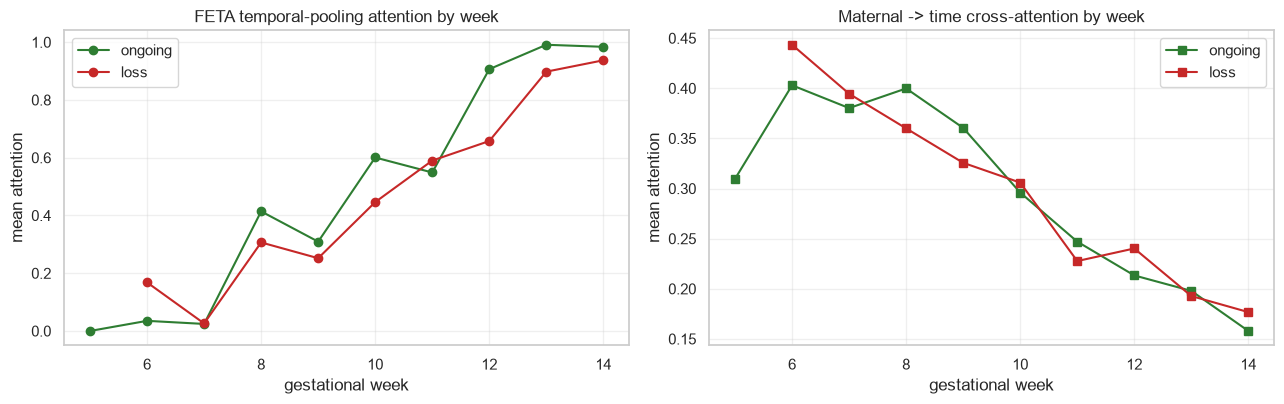

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for outcome, color in [('ongoing', '#2E7D32'), ('loss', '#C62828')]:
    sub = feta_week[feta_week['outcome'] == outcome].sort_values('gestational_week')
    ax[0].plot(sub['gestational_week'], sub['mean_temporal_attention'],
               marker='o', color=color, label=outcome)
    ax[1].plot(sub['gestational_week'], sub['mean_maternal_to_time'],
               marker='s', color=color, label=outcome)
ax[0].set_title('FETA temporal-pooling attention by week')
ax[0].set_xlabel('gestational week'); ax[0].set_ylabel('mean attention')
ax[1].set_title('Maternal -> time cross-attention by week')
ax[1].set_xlabel('gestational week'); ax[1].set_ylabel('mean attention')
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7.4 PREG-Net — node importance & edge attention on the test set

For each test patient we record the importance of every active node and the mean attention on every
active edge (averaged across GAT layers and heads). This is where we can check whether the *learned*
attention agrees with the *hand-designed* physiological graph.

In [53]:
@torch.no_grad()
def preg_attention(model, loader, gb, device=DEVICE):
    model.eval()
    src = gb.edge_index[0].numpy(); dst = gb.edge_index[1].numpy()
    etypes = gb.edge_type.numpy()
    node_rows, edge_rows, preds = [], [], []
    for batch in loader:
        pids = list(batch['patient_id'])
        b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        g = gb.batch_to_graph(b)
        g = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in g.items()}
        logits, attn = model(node_features=g['node_features'], edge_index=g['edge_index'],
                             node_types=g['node_types'], node_mask=g['node_mask'])
        prob = torch.sigmoid(logits.squeeze(-1)).cpu().numpy()
        lab  = b['label'].cpu().numpy().astype(int)
        pr   = (prob >= 0.5).astype(int)
        node_imp = attn['node_importance'].cpu().numpy()               # (B,N)
        nmask    = g['node_mask'].cpu().numpy()
        edge_mean = torch.stack(attn['edge_attention']).mean((0, 2)).cpu().numpy()  # (B,E)
        for i, pid in enumerate(pids):
            ct = case_type(lab[i], pr[i])
            preds.append({'patient_id': pid, 'label': int(lab[i]),
                          'probability': float(prob[i]), 'prediction': int(pr[i]), 'case_type': ct})
            for n in range(node_imp.shape[1]):
                if nmask[i, n] == 0:
                    continue
                m = node_meta(n)
                node_rows.append({'patient_id': pid, 'case_type': ct, 'node_index': n,
                                  'node_name': m['name'], 'node_family': m['family'],
                                  'node_feature': m['feature'], 'importance': float(node_imp[i, n])})
            for e in range(len(src)):
                si, di = int(src[e]), int(dst[e])
                if nmask[i, si] == 0 or nmask[i, di] == 0:
                    continue
                sm, dm = node_meta(si), node_meta(di)
                edge_rows.append({'patient_id': pid, 'case_type': ct,
                                  'edge_type': EDGE_TYPE_NAMES[int(etypes[e])],
                                  'clinical_group': edge_group(int(etypes[e]), sm['feature'], dm['feature']),
                                  'relationship': f"{sm['feature']}->{dm['feature']}",
                                  'source_feature': sm['feature'], 'target_feature': dm['feature'],
                                  'attention': float(edge_mean[i, e])})
    return pd.DataFrame(node_rows), pd.DataFrame(edge_rows), pd.DataFrame(preds)

preg_node_df, preg_edge_df, preg_pred_df = preg_attention(
    trained_models['preg_net'], loaders['test'], graph_builder)
print(f"node rows: {len(preg_node_df)}  |  edge rows: {len(preg_edge_df)}")

node rows: 2290  |  edge rows: 11589


### 7.5 PREG-Net node importance — which clinical variables carry the signal?

Averaged across all test patients. Higher = the model relied on that variable more when forming its
graph-level prediction.

,node_family,node_feature,mean_importance,sd_importance,n
10,temporal,YSD,0.1761,0.1851,359
8,temporal,FHR,0.0927,0.0875,359
9,temporal,GS,0.0405,0.0576,359
0,maternal,age,0.0185,0.0212,122
3,maternal,gravidity,0.0174,0.0192,122
6,maternal,singleton,0.0153,0.0173,122
5,maternal,previous_loss,0.0096,0.0109,122
4,maternal,parity,0.0078,0.0085,122
7,temporal,CRL,0.0052,0.0047,359
1,maternal,bmi,0.0049,0.0055,122


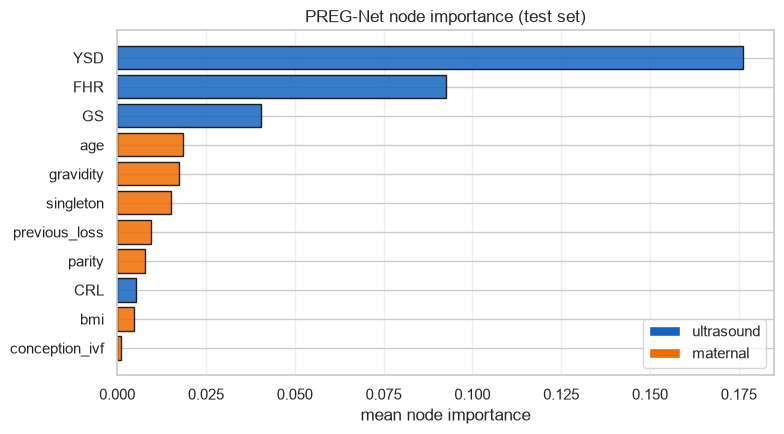

In [54]:
from matplotlib.patches import Patch

node_summary = (preg_node_df.groupby(['node_family', 'node_feature'])['importance']
                .agg(mean_importance='mean', sd_importance='std', n='count')
                .reset_index().sort_values('mean_importance', ascending=False))
display(node_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = node_summary['node_family'].map({'temporal': '#1565C0', 'maternal': '#EF6C00'})
ax.barh(node_summary['node_feature'], node_summary['mean_importance'],
        color=colors, edgecolor='black', alpha=0.85)
ax.invert_yaxis(); ax.set_xlabel('mean node importance')
ax.set_title('PREG-Net node importance (test set)')
handles = [Patch(facecolor='#1565C0', label='ultrasound'),
           Patch(facecolor='#EF6C00', label='maternal')]
ax.legend(handles=handles); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### 7.6 Edge attention vs. the knowledge-graph rationale

Do the learned edge weights favour the physiological relationships we encoded on purpose? We rank edge
groups by mean attention and single out the **primary rationale** edges (FHR→CRL, YSD→GS, CRL→GS).

Attention by clinical group:


,clinical_group,mean_attention,n
2,primary_rationale,0.1616,1077
3,temporal_same_variable,0.1350,1896
0,additional_physio,0.1339,1795
1,maternal_to_us,0.1123,6821


Top edges by mean attention:


,edge_type,clinical_group,relationship,mean_attention,sd_attention,n
24,physiological,primary_rationale,CRL->GS,0.2540,0.0850,359
18,maternal->US,maternal_to_us,previous_loss->YSD,0.1957,0.0522,359
27,temporal,temporal_same_variable,CRL->CRL,0.1905,0.0804,474
19,physiological,additional_physio,CRL->FHR,0.1858,0.0740,359
3,maternal->US,maternal_to_us,age->YSD,0.1836,0.0505,359
20,physiological,additional_physio,FHR->YSD,0.1700,0.0766,359
17,maternal->US,maternal_to_us,previous_loss->GS,0.1611,0.0380,359
30,temporal,temporal_same_variable,YSD->YSD,0.1560,0.0515,474
2,maternal->US,maternal_to_us,age->GS,0.1435,0.0381,359
26,physiological,primary_rationale,YSD->GS,0.1311,0.0291,359


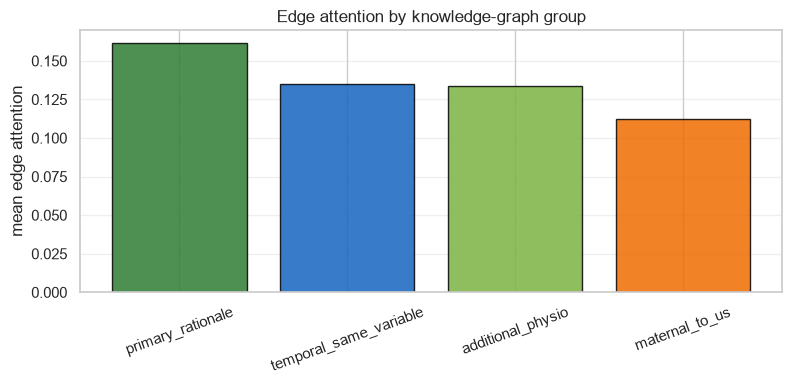

In [55]:
edge_summary = (preg_edge_df.groupby(['edge_type', 'clinical_group', 'relationship'])['attention']
                .agg(mean_attention='mean', sd_attention='std', n='count')
                .reset_index().sort_values('mean_attention', ascending=False))
group_summary = (preg_edge_df.groupby('clinical_group')['attention']
                 .agg(mean_attention='mean', n='count')
                 .reset_index().sort_values('mean_attention', ascending=False))
print("Attention by clinical group:")
display(group_summary.round(4))
print("Top edges by mean attention:")
display(edge_summary.head(10).round(4))

fig, ax = plt.subplots(figsize=(8, 4))
gcolor = {'primary_rationale': '#2E7D32', 'additional_physio': '#7CB342',
          'temporal_same_variable': '#1565C0', 'maternal_to_us': '#EF6C00'}
ax.bar(group_summary['clinical_group'], group_summary['mean_attention'],
       color=[gcolor.get(g, '#888') for g in group_summary['clinical_group']],
       edgecolor='black', alpha=0.85)
ax.set_ylabel('mean edge attention'); ax.set_title('Edge attention by knowledge-graph group')
ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 7.7 Case studies — one patient per outcome category

For a true-positive, true-negative, false-positive and false-negative (where available) we show the
model's probability and its top attention drivers — the kind of per-patient explanation a clinician
would want.

In [56]:
def top_drivers(pid):
    fatt = (feta_attn_df[feta_attn_df['patient_id'] == pid]
            .nlargest(1, 'temporal_attention'))
    top_week = int(fatt['gestational_week'].iloc[0]) if len(fatt) else None
    nn = (preg_node_df[preg_node_df['patient_id'] == pid]
          .nlargest(3, 'importance')['node_name'].tolist())
    ee = (preg_edge_df[preg_edge_df['patient_id'] == pid]
          .nlargest(2, 'attention')['relationship'].tolist())
    return top_week, nn, ee

merged = preg_pred_df.rename(columns={'probability': 'preg_prob'}).merge(
    feta_pred_df[['patient_id', 'probability']].rename(columns={'probability': 'feta_prob'}),
    on='patient_id')

case_rows = []
for ct in ['true_positive', 'true_negative', 'false_positive', 'false_negative']:
    pool = merged[merged['case_type'] == ct]
    if pool.empty:
        continue
    r = pool.iloc[0]
    week, nodes, edges = top_drivers(r['patient_id'])
    case_rows.append({'case_type': ct, 'patient_id': r['patient_id'], 'label': int(r['label']),
                      'feta_prob': round(float(r['feta_prob']), 3),
                      'preg_prob': round(float(r['preg_prob']), 3),
                      'FETA_top_week': week, 'PREG_top_nodes': ', '.join(nodes),
                      'PREG_top_edges': ', '.join(edges)})
case_studies = pd.DataFrame(case_rows)
display(case_studies)

,case_type,patient_id,label,feta_prob,preg_prob,FETA_top_week,PREG_top_nodes,PREG_top_edges
0,true_positive,P00014,1,0.959,0.994,11,"FHR_t3, GS_t3, YSD_t3","CRL->GS, previous_loss->YSD"
1,true_negative,P00002,0,0.003,0.003,12,"YSD_t5, YSD_t4, FHR_t5","CRL->GS, CRL->FHR"
2,false_positive,P00089,0,0.120,0.942,12,"FHR_t4, GS_t4, FHR_t3","CRL->GS, CRL->FHR"
3,false_negative,P00099,1,0.421,0.056,6,"YSD_t1, YSD_t2, FHR_t2","CRL->GS, YSD->YSD"


### 7.8 Persist paper-ready artifacts

Everything the manuscript's interpretability section draws on is written to `results/explainability/`
(CSV tables) plus a human-readable Markdown summary.

In [57]:
EXPLAIN_DIR = RESULTS_DIR / 'explainability'
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

feta_attn_df.to_csv(EXPLAIN_DIR / 'feta_temporal_attention.csv', index=False)
feta_week.to_csv(EXPLAIN_DIR / 'feta_attention_by_week.csv', index=False)
node_summary.to_csv(EXPLAIN_DIR / 'preg_node_importance.csv', index=False)
edge_summary.to_csv(EXPLAIN_DIR / 'preg_edge_attention.csv', index=False)
group_summary.to_csv(EXPLAIN_DIR / 'preg_edge_group_attention.csv', index=False)
case_studies.to_csv(EXPLAIN_DIR / 'case_studies.csv', index=False)

top_node = node_summary.iloc[0]
prim = group_summary[group_summary['clinical_group'] == 'primary_rationale']['mean_attention']
prim_val = float(prim.iloc[0]) if len(prim) else float('nan')
lines = [
    '# Explainability Summary (synthetic cohort)', '',
    f"- Test patients analysed: {preg_pred_df.shape[0]}",
    f"- FETA most-attended gestational week (overall): "
    f"{int(feta_attn_df.groupby('gestational_week')['temporal_attention'].mean().idxmax())}",
    f"- PREG-Net most important variable: **{top_node['node_feature']}** "
    f"({top_node['node_family']}, mean importance {top_node['mean_importance']:.4f})",
    f"- Mean attention on primary-rationale physiological edges: {prim_val:.4f}", '',
    '## Node importance (top 5)', '',
    node_summary.head(5).round(4).to_markdown(index=False), '',
    '## Edge attention by clinical group', '',
    group_summary.round(4).to_markdown(index=False), '',
    '## Case studies', '',
    case_studies.to_markdown(index=False), '',
    '> All figures derive from synthetic data; they demonstrate model interpretability, not clinical findings.',
]
(EXPLAIN_DIR / 'explainability_summary.md').write_text('\n'.join(lines))
print('Wrote artifacts to', EXPLAIN_DIR)
for p in sorted(EXPLAIN_DIR.glob('*')):
    print('  -', p.name)

Wrote artifacts to results/explainability


  - case_studies.csv
  - case_studies.md
  - explainability_summary.md
  - feta_attention_by_gestational_week.csv
  - feta_attention_by_week.csv
  - feta_predictions_with_cross_attention.csv
  - feta_temporal_attention.csv
  - feta_temporal_attention_by_scan.csv
  - manifest.json
  - patient_graphs
  - patient_trajectories
  - preg_clinical_edge_comparison.csv
  - preg_edge_attention.csv
  - preg_edge_attention_summary.csv
  - preg_edge_group_attention.csv
  - preg_node_importance.csv
  - preg_node_importance_summary.csv
  - summary.md


---
## Layer 7 — Manuscript Figures

The nine figures embedded in the manuscript (`FETA_PREGNet_Formatted.docx`), regenerated here so the
whole pipeline — data through publication figures — lives in one notebook. Figures 5, 7, 8 and 9 read
directly from the in-memory results of Layer 5/6 above (`test_preds`, `feta_attn_df`, `node_summary`,
`preg_edge_df`), so they always match whatever this run just trained — no dependency on saved CSVs that
could be stale. Figure 6 (cross-validation) is the one exception: it reads
`results/cross_validation/summary.csv`, produced by the separate `scripts/cross_validate.py` (5-fold
retraining isn't part of this notebook); it prints a message and skips itself if that file isn't there
yet. All nine PNGs are written to `figures/`.

### 8.0 Setup — palette and shared helpers

Resets matplotlib to its defaults (undoing the Seaborn theme from cell 2 so these figures match the
manuscript's plain, paper-ready style), then defines the shared colour palette, the model
display-name/proposed-vs-baseline map, and a `save_fig` helper that writes to `figures/` and shows the
plot inline.

In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib.lines import Line2D
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                              average_precision_score, confusion_matrix)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

# Colour palette (colour-blind friendly, consistent across all 9 figures)
C = {
    "viable": "#2C7FB8", "loss": "#D95F02",
    "us": "#1B9E77", "mat": "#7570B3",
    "phys": "#D95F02", "temp": "#2C7FB8", "m2u": "#7570B3",
    "proposed": "#B2182B", "baseline": "#9E9E9E",
    "box": "#F2F5F8", "boxedge": "#37474F",
}

# key -> (display name, is_proposed) for the 9 models scored in Layer 5's test_preds
MODEL_DISPLAY = {
    "feta_transformer":      ("FETA-Transformer", True),
    "preg_net":              ("PREG-Net", True),
    "ensemble":              ("Ensemble (avg)", True),
    "ensemble_learned":      ("Ensemble (learned)", True),
    "logistic_regression":   ("Logistic regression", False),
    "random_forest":         ("Random forest", False),
    "xgboost":               ("XGBoost", False),
    "hist_gradient_boosting":("HistGradientBoosting", False),
    "mlp":                   ("MLP", False),
}

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path)
    print("wrote", path)
    plt.show()
    plt.close(fig)

print("Manuscript-figure setup ready ->", FIG_DIR.resolve())


Manuscript-figure setup ready -> /Users/techabhi/Desktop/Preg-Feta/figures


### 8.1 Figure 1 — Framework overview

Six-stage schematic of the whole pipeline; no data dependency, pure diagram.

wrote figures/fig1_framework_overview.png


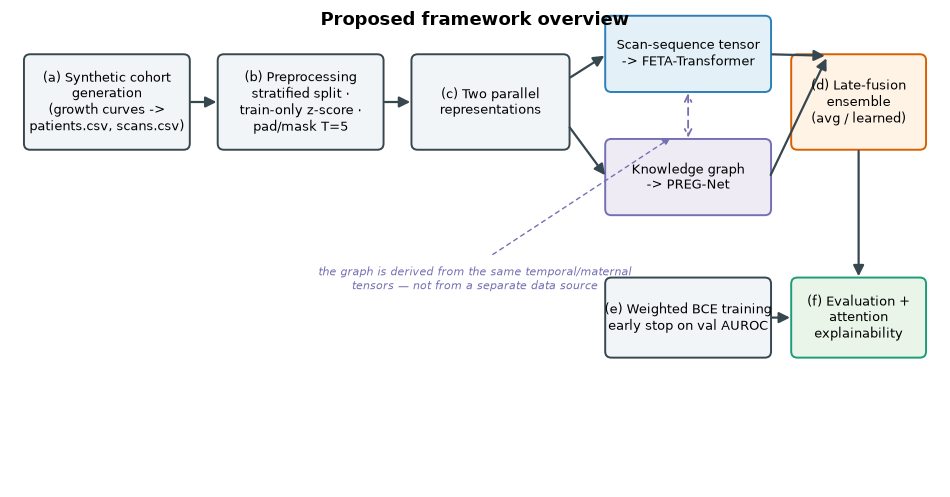

In [59]:
fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.2); ax.axis("off")

def box(x, y, w, h, text, fc=C["box"], ec=C["boxedge"], fs=9):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.08",
                 fc=fc, ec=ec, lw=1.4))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fs, wrap=True)

def arrow(x1, y1, x2, y2, color=C["boxedge"], style="-|>", lw=1.6):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                 mutation_scale=16, color=color, lw=lw))

ymid = 4.4
box(0.2, ymid, 2.1, 1.2, "(a) Synthetic cohort\ngeneration\n(growth curves ->\npatients.csv, scans.csv)")
box(2.7, ymid, 2.1, 1.2, "(b) Preprocessing\nstratified split ·\ntrain-only z-score ·\npad/mask T=5")
box(5.2, ymid, 2.0, 1.2, "(c) Two parallel\nrepresentations")

box(7.7, 5.15, 2.1, 0.95, "Scan-sequence tensor\n-> FETA-Transformer",
    fc="#E3F0F7", ec=C["viable"])
box(7.7, 3.55, 2.1, 0.95, "Knowledge graph\n-> PREG-Net",
    fc="#EFEBF5", ec=C["mat"])

box(10.1, ymid, 1.7, 1.2, "(d) Late-fusion\nensemble\n(avg / learned)",
    fc="#FFF3E6", ec=C["loss"])

box(7.7, 1.7, 2.1, 1.0, "(e) Weighted BCE training\nearly stop on val AUROC")
box(10.1, 1.7, 1.7, 1.0, "(f) Evaluation +\nattention\nexplainability",
    fc="#EAF5EA", ec=C["us"])

arrow(2.3, ymid + 0.6, 2.7, ymid + 0.6)
arrow(4.8, ymid + 0.6, 5.2, ymid + 0.6)
arrow(7.2, ymid + 0.9, 7.7, 5.62)
arrow(7.2, ymid + 0.3, 7.7, 4.02)
arrow(9.8, 5.62, 10.55, ymid + 1.2)
arrow(9.8, 4.02, 10.55, ymid + 1.2)
arrow(10.95, ymid, 10.95, 2.7)
arrow(9.8, 2.2, 10.1, 2.2)

ax.add_patch(FancyArrowPatch((8.75, 5.15), (8.75, 4.5),
             arrowstyle="<->", mutation_scale=12,
             color=C["mat"], lw=1.3, linestyle=(0, (4, 3))))
ax.add_patch(FancyArrowPatch((6.2, 3.0), (8.55, 4.55),
             arrowstyle="-|>", mutation_scale=11,
             color=C["mat"], lw=1.0, linestyle=(0, (3, 3))))
ax.text(6.0, 2.7, "the graph is derived from the same temporal/maternal\n"
                  "tensors — not from a separate data source",
        fontsize=8, color=C["mat"], ha="center", va="center", style="italic")

ax.text(6.0, 6.0, "Proposed framework overview", ha="center",
        fontsize=13, fontweight="bold")
save_fig(fig, "fig1_framework_overview.png")


### 8.2 Figure 2 — FETA-Transformer architecture

Vertical schematic of the forward pass; no data dependency.

wrote figures/fig2_feta_architecture.png


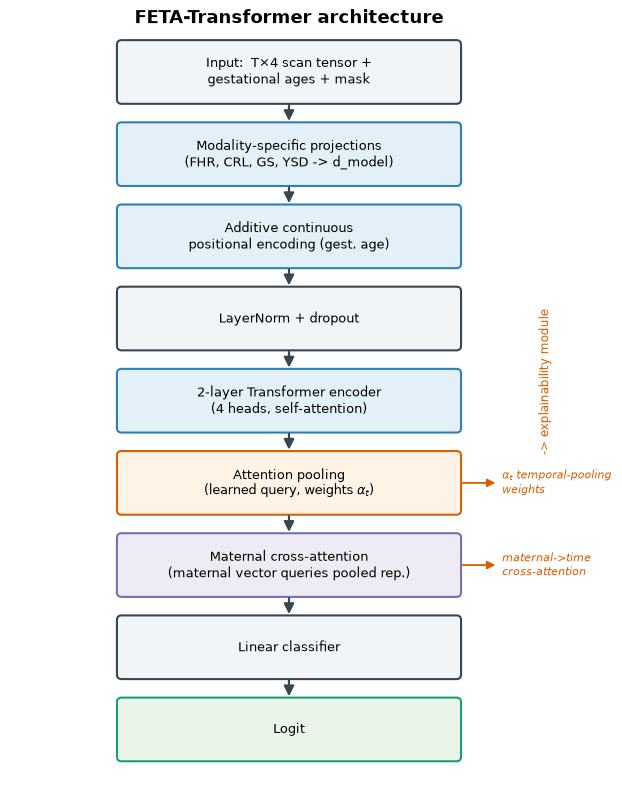

In [60]:
fig, ax = plt.subplots(figsize=(7.2, 10))
ax.set_xlim(0, 7.2); ax.set_ylim(0, 10.4); ax.axis("off")
cx = 3.6
w = 4.4

stages = [
    ("Input:  T×4 scan tensor +\ngestational ages + mask", "#F2F5F8", C["boxedge"]),
    ("Modality-specific projections\n(FHR, CRL, GS, YSD -> d_model)", "#E3F0F7", C["viable"]),
    ("Additive continuous\npositional encoding (gest. age)", "#E3F0F7", C["viable"]),
    ("LayerNorm + dropout", "#F2F5F8", C["boxedge"]),
    ("2-layer Transformer encoder\n(4 heads, self-attention)", "#E3F0F7", C["viable"]),
    ("Attention pooling\n(learned query, weights $\\alpha_t$)", "#FFF3E6", C["loss"]),
    ("Maternal cross-attention\n(maternal vector queries pooled rep.)", "#EFEBF5", C["mat"]),
    ("Linear classifier", "#F2F5F8", C["boxedge"]),
    ("Logit", "#EAF5EA", C["us"]),
]
n = len(stages)
h = 0.82
gap = (10.0 - 0.3 - n * h) / (n - 1)
y = 10.0 - h
centers = []
for text, fc, ec in stages:
    ax.add_patch(FancyBboxPatch((cx - w / 2, y), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.06",
                 fc=fc, ec=ec, lw=1.5))
    ax.text(cx, y + h / 2, text, ha="center", va="center", fontsize=9)
    centers.append(y + h / 2)
    y -= (h + gap)

for i in range(n - 1):
    y_top = centers[i] - h / 2
    y_bot = centers[i + 1] + h / 2
    ax.add_patch(FancyArrowPatch((cx, y_top), (cx, y_bot),
                 arrowstyle="-|>", mutation_scale=15, color=C["boxedge"], lw=1.6))

for idx, label in [(5, "$\\alpha_t$ temporal-pooling\nweights"),
                   (6, "maternal->time\ncross-attention")]:
    yc = centers[idx]
    ax.add_patch(FancyArrowPatch((cx + w / 2, yc), (cx + w / 2 + 0.5, yc),
                 arrowstyle="-|>", mutation_scale=12, color=C["loss"], lw=1.3))
    ax.text(cx + w / 2 + 0.55, yc, label, ha="left", va="center",
            fontsize=8, color=C["loss"], style="italic")

ax.text(cx, 10.25, "FETA-Transformer architecture", ha="center",
        fontsize=13, fontweight="bold")
ax.text(6.9, 5.4, "-> explainability module", rotation=90, ha="center",
        va="center", fontsize=8.5, color=C["loss"])
save_fig(fig, "fig2_feta_architecture.png")


### 8.3 Figure 3 — PREG-Net architecture and knowledge graph

Left panel: the 27-node graph (schematic layout). Right panel: the GAT processing pipeline. No data dependency.

wrote figures/fig3_pregnet_architecture.png


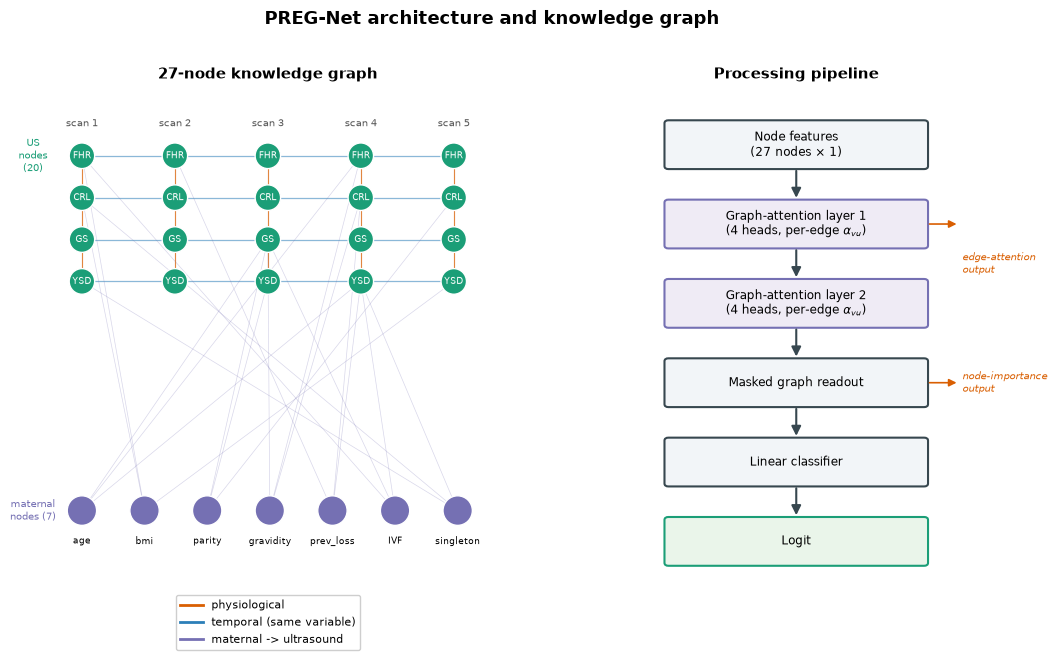

In [69]:
fig, (axg, axp) = plt.subplots(1, 2, figsize=(12.5, 6.4),
                               gridspec_kw={"width_ratios": [1.25, 1]})
axg.set_xlim(0, 10); axg.set_ylim(0, 10); axg.axis("off")
axg.set_title("27-node knowledge graph")

vars4 = ["FHR", "CRL", "GS", "YSD"]
mat7 = ["age", "bmi", "parity", "gravidity", "prev_loss", "IVF", "singleton"]
us_pos = {}
for t in range(5):
    x = 1.2 + t * 1.9
    for v, var in enumerate(vars4):
        y = 8.6 - v * 0.85
        us_pos[(t, var)] = (x, y)
mat_pos = {}
for m, name in enumerate(mat7):
    x = 1.2 + m * 1.28
    mat_pos[name] = (x, 1.4)

for var in vars4:
    for t in range(4):
        a = us_pos[(t, var)]; b = us_pos[(t + 1, var)]
        axg.plot([a[0], b[0]], [a[1], b[1]], color=C["temp"], lw=0.9, alpha=0.55, zorder=1)
phys_pairs = [("FHR", "CRL"), ("CRL", "GS"), ("GS", "YSD"), ("FHR", "YSD")]
for t in range(5):
    for a, b in phys_pairs:
        pa = us_pos[(t, a)]; pb = us_pos[(t, b)]
        axg.plot([pa[0], pb[0]], [pa[1], pb[1]], color=C["phys"], lw=0.8, alpha=0.5, zorder=1)
rng = np.random.default_rng(0)
for name in mat7:
    mp = mat_pos[name]
    targets = [(t, v) for t in range(5) for v in vars4]
    for tt in rng.choice(len(targets), size=3, replace=False):
        up = us_pos[targets[tt]]
        axg.plot([mp[0], up[0]], [mp[1], up[1]], color=C["m2u"], lw=0.5, alpha=0.28, zorder=1)

for (t, var), (x, y) in us_pos.items():
    axg.add_patch(Circle((x, y), 0.26, fc=C["us"], ec="white", lw=1, zorder=3))
    axg.text(x, y, var, ha="center", va="center", fontsize=6.2, color="white", zorder=4)
for name, (x, y) in mat_pos.items():
    axg.add_patch(Circle((x, y), 0.30, fc=C["mat"], ec="white", lw=1, zorder=3))
    axg.text(x, y - 0.62, name, ha="center", va="center", fontsize=6.4, zorder=4)

for t in range(5):
    axg.text(1.2 + t * 1.9, 9.2, f"scan {t+1}", ha="center", fontsize=7.5, color="#555")
axg.text(0.2, 8.6, "US\nnodes\n(20)", fontsize=7.5, color=C["us"], ha="center", va="center")
axg.text(0.2, 1.4, "maternal\nnodes (7)", fontsize=7.5, color=C["mat"], ha="center", va="center")

legend = [
    Line2D([0], [0], color=C["phys"], lw=2, label="physiological"),
    Line2D([0], [0], color=C["temp"], lw=2, label="temporal (same variable)"),
    Line2D([0], [0], color=C["m2u"], lw=2, label="maternal -> ultrasound"),
]
axg.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=1,
    fontsize=8,
    frameon=True,
    framealpha=0.95,
)
axp.set_xlim(0, 6); axp.set_ylim(0, 10); axp.axis("off")
axp.set_title("Processing pipeline")
steps = [
    ("Node features\n(27 nodes × 1)", "#F2F5F8", C["boxedge"]),
    ("Graph-attention layer 1\n(4 heads, per-edge $\\alpha_{vu}$)", "#EFEBF5", C["mat"]),
    ("Graph-attention layer 2\n(4 heads, per-edge $\\alpha_{vu}$)", "#EFEBF5", C["mat"]),
    ("Masked graph readout", "#F2F5F8", C["boxedge"]),
    ("Linear classifier", "#F2F5F8", C["boxedge"]),
    ("Logit", "#EAF5EA", C["us"]),
]
ns = len(steps); h = 0.95
gap = (9.0 - ns * h) / (ns - 1)
y = 9.3 - h; centers = []
for text, fc, ec in steps:
    axp.add_patch(FancyBboxPatch((1.0, y), 4.0, h,
                 boxstyle="round,pad=0.02,rounding_size=0.06",
                 fc=fc, ec=ec, lw=1.5))
    axp.text(3.0, y + h / 2, text, ha="center", va="center", fontsize=8.6)
    centers.append(y + h / 2); y -= (h + gap)
for i in range(ns - 1):
    axp.add_patch(FancyArrowPatch((3.0, centers[i] - h / 2), (3.0, centers[i + 1] + h / 2),
                 arrowstyle="-|>", mutation_scale=14, color=C["boxedge"], lw=1.5))
axp.add_patch(FancyArrowPatch((5.0, centers[1]), (5.5, centers[1]),
             arrowstyle="-|>", mutation_scale=11, color=C["loss"], lw=1.2))
axp.text(5.55, (centers[1] + centers[2]) / 2, "edge-attention\noutput", fontsize=7.5,
         color=C["loss"], ha="left", va="center", style="italic")
axp.add_patch(FancyArrowPatch((5.0, centers[3]), (5.5, centers[3]),
             arrowstyle="-|>", mutation_scale=11, color=C["loss"], lw=1.2))
axp.text(5.55, centers[3], "node-importance\noutput", fontsize=7.5,
         color=C["loss"], ha="left", va="center", style="italic")

fig.suptitle("PREG-Net architecture and knowledge graph", fontsize=13, fontweight="bold", y=1.0)
save_fig(fig, "fig3_pregnet_architecture.png")


### 8.4 Figure 4 — Cohort and trajectory visualization

Reads the synthetic cohort straight from `PATIENTS_CSV`/`SCANS_CSV` (defined in Layer 1).

wrote figures/fig4_cohort_trajectories.png


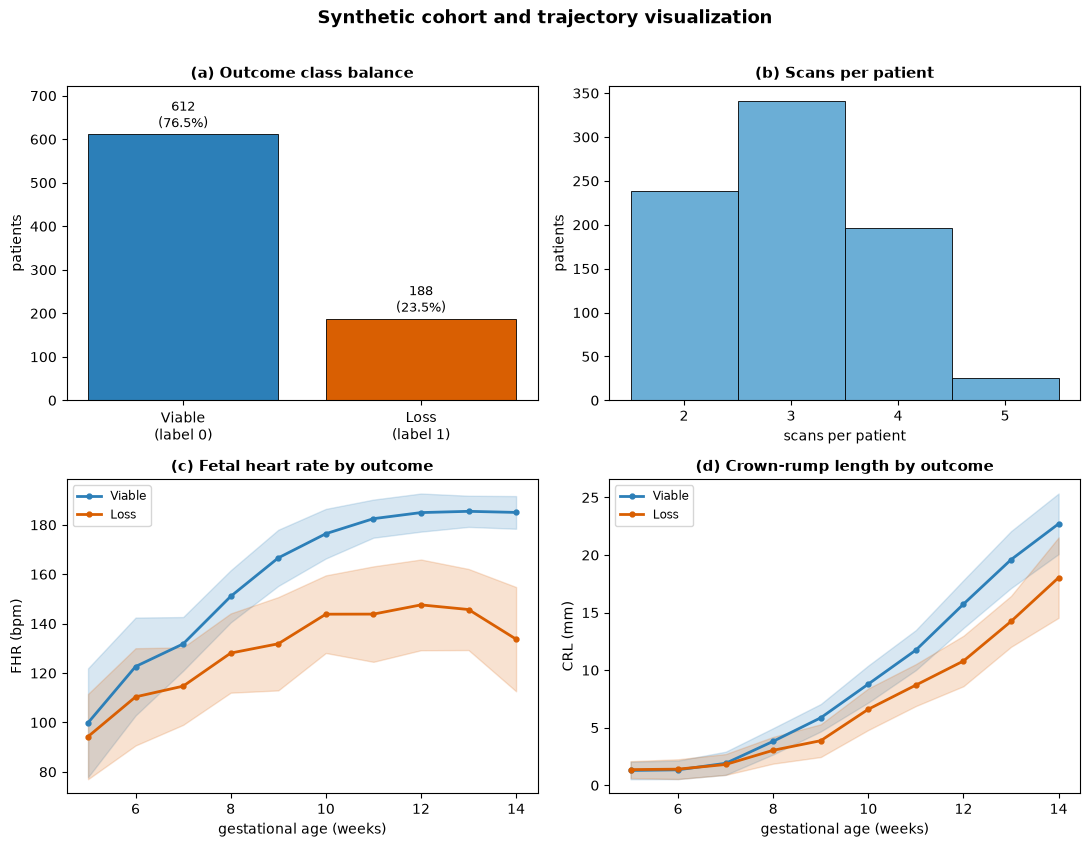

In [62]:
patients4 = pd.read_csv(PATIENTS_CSV)
scans4 = pd.read_csv(SCANS_CSV)
lab4 = patients4.set_index("patient_id")["label"]
scans4 = scans4.join(lab4, on="patient_id")

fig, axes = plt.subplots(2, 2, figsize=(11, 8.6))

ax = axes[0, 0]
vc = patients4["label"].value_counts().reindex([0, 1])
bars = ax.bar(["Viable\n(label 0)", "Loss\n(label 1)"], vc.values,
              color=[C["viable"], C["loss"]], edgecolor="black", lw=0.6)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 6, f"{v}\n({v/len(patients4)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("patients"); ax.set_title("(a) Outcome class balance")
ax.set_ylim(0, vc.max() * 1.18)

ax = axes[0, 1]
spp = scans4.groupby("patient_id").size()
bins = np.arange(spp.min() - 0.5, spp.max() + 1.5, 1)
ax.hist(spp, bins=bins, color="#6BAED6", edgecolor="black", lw=0.6)
ax.set_xlabel("scans per patient"); ax.set_ylabel("patients")
ax.set_title("(b) Scans per patient")
ax.set_xticks(range(int(spp.min()), int(spp.max()) + 1))

def traj4(ax, col, title, ylab):
    for label, color, name in [(0, C["viable"], "Viable"), (1, C["loss"], "Loss")]:
        sub = scans4[scans4["label"] == label].copy()
        sub["gw"] = sub["gestational_age_weeks"].round().astype(int)
        g = sub.groupby("gw")[col]
        m = g.mean(); sd = g.std().fillna(0)
        wk = m.index.values
        ax.plot(wk, m.values, color=color, lw=2, marker="o", ms=3.5, label=name)
        ax.fill_between(wk, m - sd, m + sd, color=color, alpha=0.18)
    ax.set_xlabel("gestational age (weeks)"); ax.set_ylabel(ylab)
    ax.set_title(title); ax.legend(fontsize=8.5)

traj4(axes[1, 0], "FHR", "(c) Fetal heart rate by outcome", "FHR (bpm)")
traj4(axes[1, 1], "CRL", "(d) Crown-rump length by outcome", "CRL (mm)")

fig.suptitle("Synthetic cohort and trajectory visualization", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
save_fig(fig, "fig4_cohort_trajectories.png")


### 8.5 Figure 5 — ROC and precision–recall curves

Reuses `test_preds` from §6.1/6.2 directly, so the AUROC/AUPRC in the legend always match whatever this run just scored — no separate file to go stale.

wrote figures/fig5_roc_pr.png


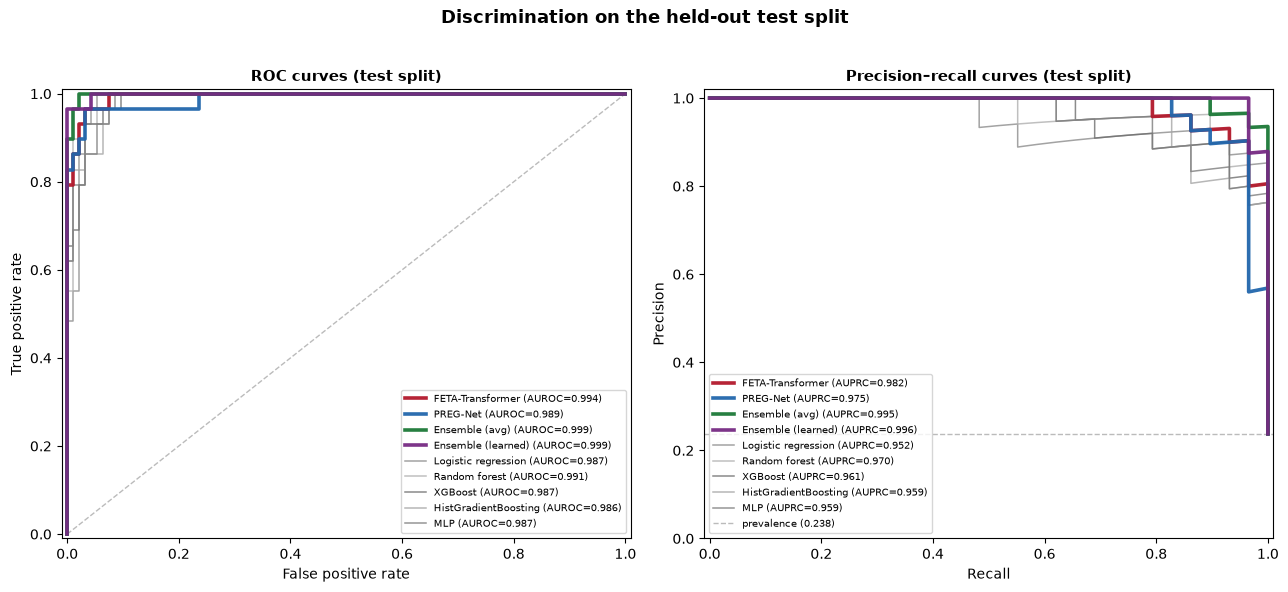

In [63]:
fig, (axr, axp) = plt.subplots(1, 2, figsize=(13, 6))
prevalence = None
proposed_colors = {
    "FETA-Transformer": "#B2182B", "PREG-Net": "#2166AC",
    "Ensemble (avg)": "#1B7837", "Ensemble (learned)": "#762A83",
}
baseline_colors = ["#8C8C8C", "#B0B0B0", "#6E6E6E", "#A5A5A5", "#7C7C7C"]
bi = 0
ordered_keys = [k for k in MODEL_DISPLAY if MODEL_DISPLAY[k][1]] + \
               [k for k in MODEL_DISPLAY if not MODEL_DISPLAY[k][1]]
for key in ordered_keys:
    if key not in test_preds:
        continue
    name, is_prop = MODEL_DISPLAY[key]
    y, p = test_preds[key]
    if prevalence is None:
        prevalence = y.mean()
    au = roc_auc_score(y, p); ap = average_precision_score(y, p)
    fpr, tpr, _ = roc_curve(y, p)
    prec, rec, _ = precision_recall_curve(y, p)
    if is_prop:
        col = proposed_colors[name]; lw = 2.6; z = 5; alpha = 0.95
    else:
        col = baseline_colors[bi % len(baseline_colors)]; bi += 1
        lw = 1.1; z = 2; alpha = 0.8
    axr.plot(fpr, tpr, color=col, lw=lw, zorder=z, alpha=alpha,
             label=f"{name} (AUROC={au:.3f})")
    axp.plot(rec, prec, color=col, lw=lw, zorder=z, alpha=alpha,
             label=f"{name} (AUPRC={ap:.3f})")

axr.plot([0, 1], [0, 1], ls="--", color="#BBBBBB", lw=1)
axr.set_xlabel("False positive rate"); axr.set_ylabel("True positive rate")
axr.set_title("ROC curves (test split)")
axr.set_xlim(-0.01, 1.01); axr.set_ylim(-0.01, 1.01)
axr.legend(fontsize=7.4, loc="lower right")

axp.axhline(prevalence, ls="--", color="#BBBBBB", lw=1,
            label=f"prevalence ({prevalence:.3f})")
axp.set_xlabel("Recall"); axp.set_ylabel("Precision")
axp.set_title("Precision–recall curves (test split)")
axp.set_xlim(-0.01, 1.01); axp.set_ylim(0.0, 1.02)
axp.legend(fontsize=7.4, loc="lower left")

fig.suptitle("Discrimination on the held-out test split", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "fig5_roc_pr.png")


### 8.6 Figure 6 — Cross-validation forest plot

**External dependency**: reads `results/cross_validation/summary.csv`, produced by `python scripts/cross_validate.py --models ... --n-folds 5 ...` (see CLAUDE.md). That pipeline is not part of this notebook, so this cell prints a message and skips itself if the file is missing rather than failing.

wrote figures/fig6_cv_forest.png


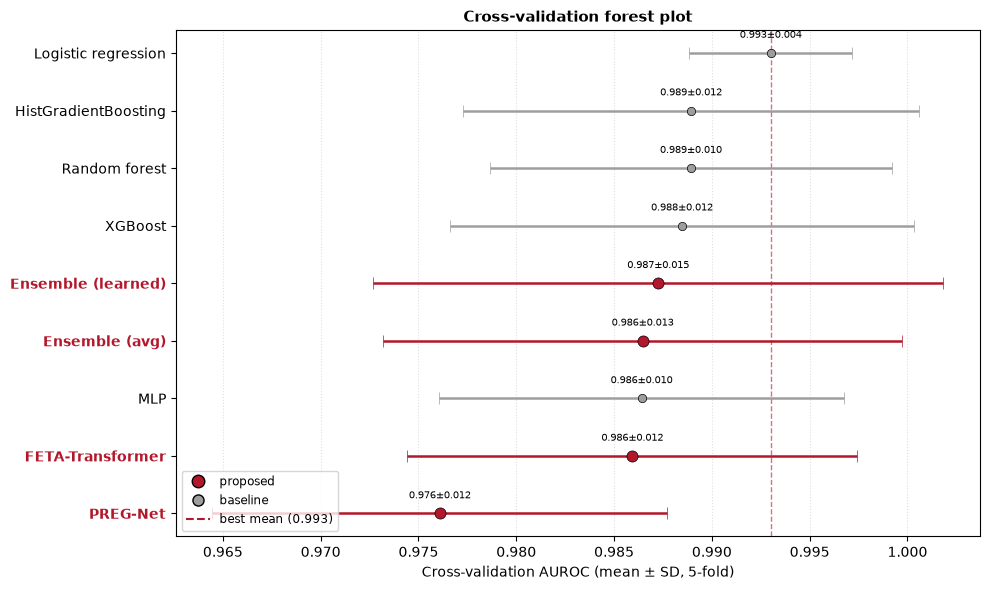

In [64]:
cv_path = RESULTS_DIR / "cross_validation" / "summary.csv"
if not cv_path.exists():
    print(f"Skipping Figure 6 - {cv_path} not found.")
    print("Run `python scripts/cross_validate.py --models preg,feta,ensemble,learned_ensemble,"
          "torch_mlp,sklearn_logistic_regression,random_forest,hist_gradient_boosting,xgboost "
          "--n-folds 5 --epochs 80 --device cpu --out-dir results/cross_validation` first.")
else:
    cv = pd.read_csv(cv_path)
    cv = cv[cv["split"] == "test"].copy()
    cv_name_map = {
        "feta": ("FETA-Transformer", True),
        "preg": ("PREG-Net", True),
        "ensemble": ("Ensemble (avg)", True),
        "learned_ensemble": ("Ensemble (learned)", True),
        "sklearn_logistic_regression": ("Logistic regression", False),
        "random_forest": ("Random forest", False),
        "xgboost": ("XGBoost", False),
        "hist_gradient_boosting": ("HistGradientBoosting", False),
        "torch_mlp": ("MLP", False),
    }
    cv["disp"] = cv["model"].map(lambda m: cv_name_map[m][0])
    cv["proposed"] = cv["model"].map(lambda m: cv_name_map[m][1])
    cv = cv.sort_values("auroc_mean")

    fig, ax = plt.subplots(figsize=(10, 6))
    ys = np.arange(len(cv))
    for y, (_, r) in zip(ys, cv.iterrows()):
        col = C["proposed"] if r["proposed"] else C["baseline"]
        ax.errorbar(r["auroc_mean"], y, xerr=r["auroc_std"], fmt="o",
                    color=col, ecolor=col, elinewidth=1.8, capsize=4,
                    ms=8 if r["proposed"] else 6,
                    markeredgecolor="black", markeredgewidth=0.5, zorder=3)
        ax.text(r["auroc_mean"], y + 0.22,
                f"{r['auroc_mean']:.3f}±{r['auroc_std']:.3f}",
                ha="center", va="bottom", fontsize=7.5)
    best = cv["auroc_mean"].max()
    ax.axvline(best, ls="--", color="#B2182B", lw=1, alpha=0.6,
               label=f"best mean ({best:.3f})")
    ax.set_yticks(ys)
    ax.set_yticklabels(cv["disp"])
    for tick, prop in zip(ax.get_yticklabels(), cv["proposed"]):
        if prop:
            tick.set_fontweight("bold"); tick.set_color(C["proposed"])
    ax.set_xlabel("Cross-validation AUROC (mean ± SD, 5-fold)")
    ax.set_title("Cross-validation forest plot")
    handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=C["proposed"],
                      markeredgecolor="black", ms=9, label="proposed"),
               Line2D([0], [0], marker="o", color="w", markerfacecolor=C["baseline"],
                      markeredgecolor="black", ms=8, label="baseline")]
    ax.legend(handles=handles + [Line2D([0], [0], ls="--", color="#B2182B", label=f"best mean ({best:.3f})")],
              loc="lower left", fontsize=8.5)
    ax.grid(axis="x", ls=":", alpha=0.4)
    fig.tight_layout()
    save_fig(fig, "fig6_cv_forest.png")


### 8.7 Figure 7 — Confusion matrices

Same `test_preds` as Figure 5, at the four proposed models, threshold 0.5.

wrote figures/fig7_confusion_matrices.png


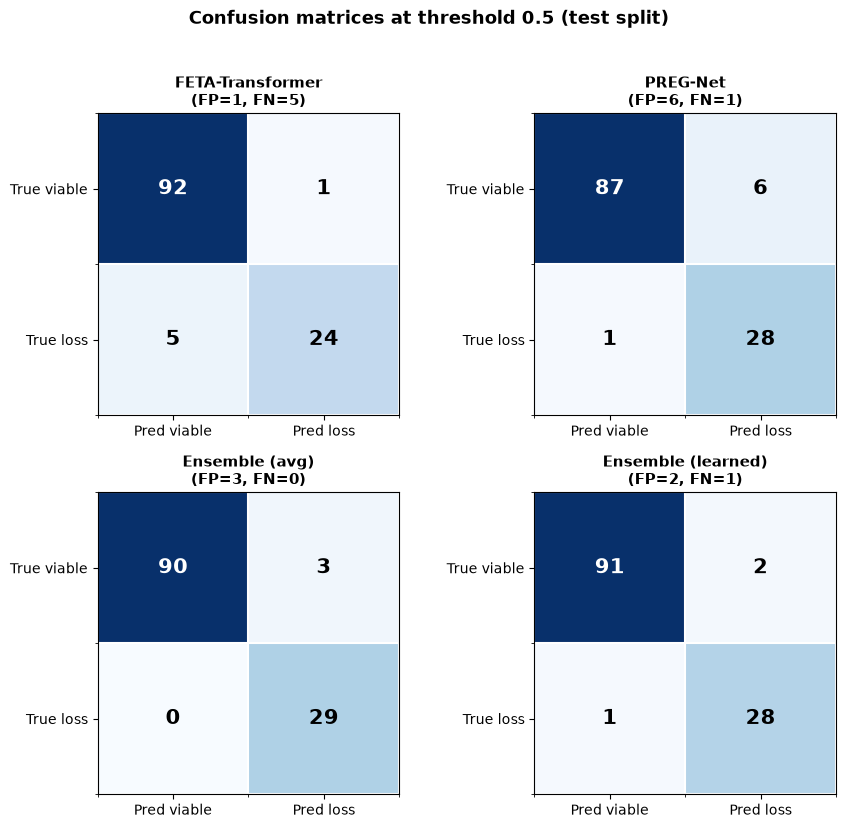

In [65]:
models7 = [
    ("FETA-Transformer", "feta_transformer"),
    ("PREG-Net", "preg_net"),
    ("Ensemble (avg)", "ensemble"),
    ("Ensemble (learned)", "ensemble_learned"),
]
fig, axes = plt.subplots(2, 2, figsize=(9, 8.4))
for ax, (name, key) in zip(axes.flat, models7):
    yt, yp = test_preds[key]
    pred = (yp >= 0.5).astype(int)
    cm = confusion_matrix(yt, pred, labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=15, fontweight="bold",
                    color="white" if val > cm.max() * 0.55 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred viable", "Pred loss"])
    ax.set_yticklabels(["True viable", "True loss"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\n(FP={fp}, FN={fn})", fontsize=10.5)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", lw=1.5)
fig.suptitle("Confusion matrices at threshold 0.5 (test split)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "fig7_confusion_matrices.png")


### 8.8 Figure 8 — FETA temporal attention by gestational week

Re-aggregates `feta_attn_df` from §7.2 with mean **and** SD (the notebook's own `feta_week` only kept the mean), so the shaded band renders the same as in the manuscript.

wrote figures/fig8_feta_attention.png


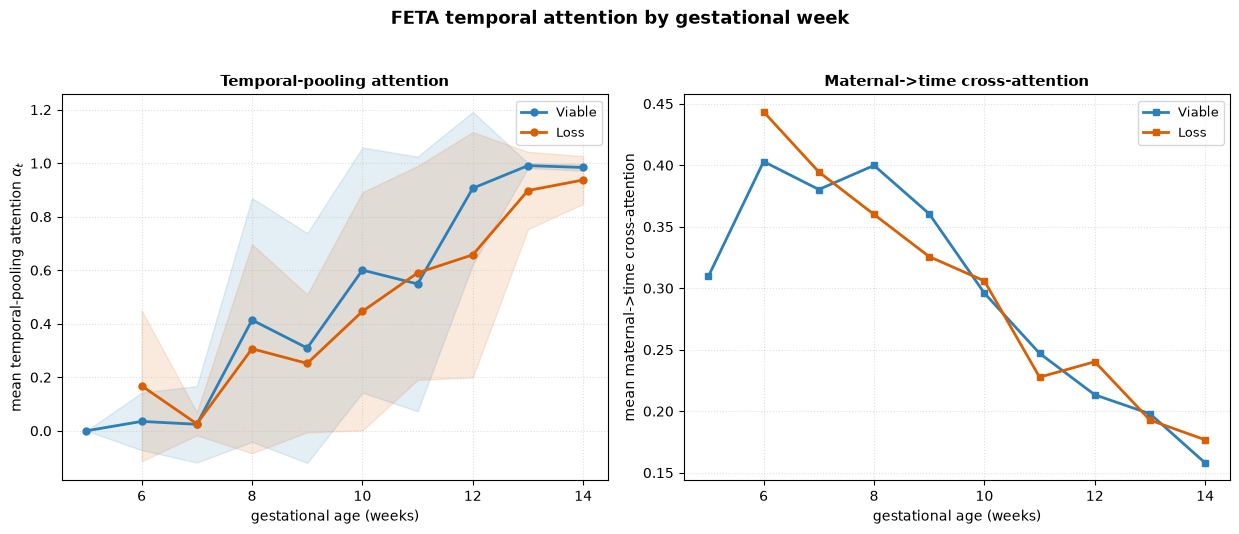

In [66]:
feta_gw = (feta_attn_df.assign(outcome=feta_attn_df["label"].map({0: "ongoing", 1: "loss"}))
           .groupby(["outcome", "gestational_week"])
           .agg(mean_temporal_attention=("temporal_attention", "mean"),
                sd_temporal_attention=("temporal_attention", "std"),
                mean_maternal_to_temporal_attention=("maternal_to_time_attention", "mean"))
           .reset_index())
feta_gw["sd_temporal_attention"] = feta_gw["sd_temporal_attention"].fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.4))
for outcome, color, name in [("ongoing", C["viable"], "Viable"), ("loss", C["loss"], "Loss")]:
    sub = feta_gw[feta_gw["outcome"] == outcome].sort_values("gestational_week")
    ax1.plot(sub["gestational_week"], sub["mean_temporal_attention"],
             color=color, lw=2, marker="o", ms=5, label=name)
    ax1.fill_between(sub["gestational_week"],
                     sub["mean_temporal_attention"] - sub["sd_temporal_attention"],
                     sub["mean_temporal_attention"] + sub["sd_temporal_attention"],
                     color=color, alpha=0.13)
    ax2.plot(sub["gestational_week"], sub["mean_maternal_to_temporal_attention"],
             color=color, lw=2, marker="s", ms=5, label=name)
ax1.set_xlabel("gestational age (weeks)")
ax1.set_ylabel("mean temporal-pooling attention $\\alpha_t$")
ax1.set_title("Temporal-pooling attention")
ax1.legend(fontsize=9); ax1.grid(ls=":", alpha=0.4)
ax2.set_xlabel("gestational age (weeks)")
ax2.set_ylabel("mean maternal->time cross-attention")
ax2.set_title("Maternal->time cross-attention")
ax2.legend(fontsize=9); ax2.grid(ls=":", alpha=0.4)
fig.suptitle("FETA temporal attention by gestational week", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, "fig8_feta_attention.png")


### 8.9 Figure 9 — PREG-Net node importance and edge attention

Left panel reuses `node_summary` from §7.5 directly. Right panel re-groups `preg_edge_df` from §7.4 by its native `edge_type` (physiological / temporal / maternal->US) rather than the finer `clinical_group` used in §7.6, to match the 3-family view in the manuscript figure.

wrote figures/fig9_pregnet_explainability.png


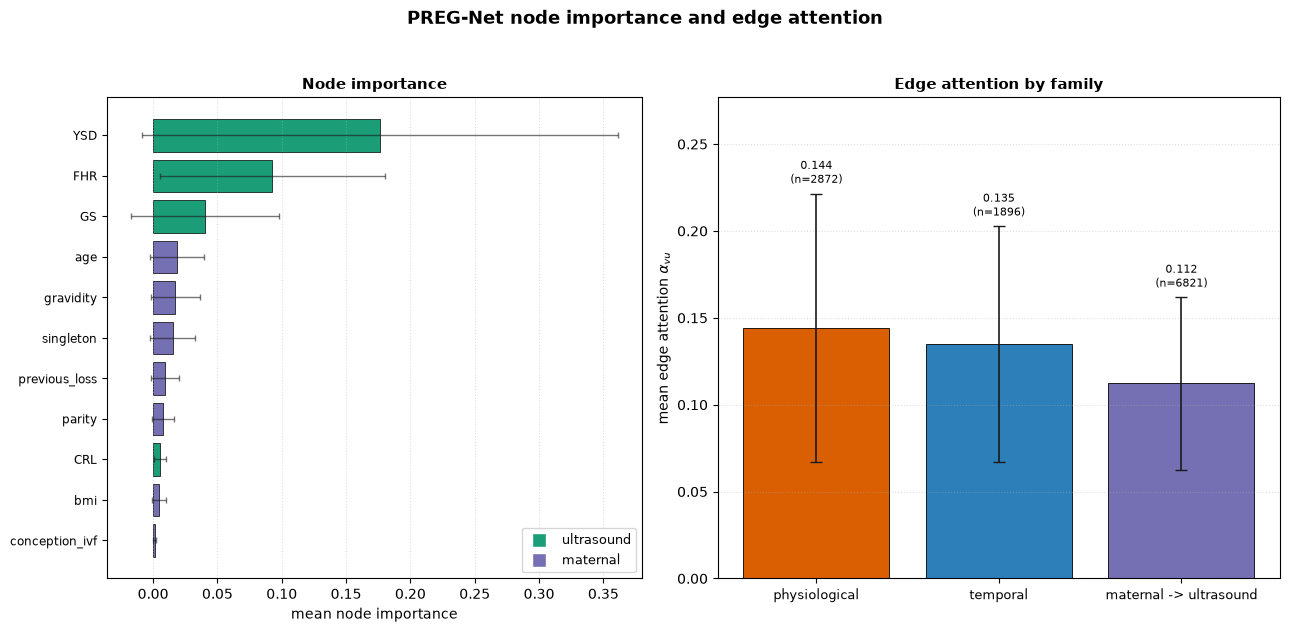

In [67]:
fig, (axn, axe) = plt.subplots(1, 2, figsize=(13, 6.4),
                               gridspec_kw={"width_ratios": [1, 1.05]})

node9 = node_summary.sort_values("mean_importance")
colors9 = [C["us"] if f == "temporal" else C["mat"] for f in node9["node_family"]]
ys = np.arange(len(node9))
axn.barh(ys, node9["mean_importance"], xerr=node9["sd_importance"],
         color=colors9, edgecolor="black", lw=0.5,
         error_kw=dict(elinewidth=1, capsize=2, alpha=0.6))
axn.set_yticks(ys); axn.set_yticklabels(node9["node_feature"], fontsize=8.5)
axn.set_xlabel("mean node importance")
axn.set_title("Node importance")
handles = [Line2D([0], [0], marker="s", color="w", markerfacecolor=C["us"], ms=10, label="ultrasound"),
           Line2D([0], [0], marker="s", color="w", markerfacecolor=C["mat"], ms=10, label="maternal")]
axn.legend(handles=handles, fontsize=9, loc="lower right")
axn.grid(axis="x", ls=":", alpha=0.4)

fam_map = {"physiological": C["phys"], "temporal": C["temp"], "maternal->US": C["m2u"]}
fam_disp = {"physiological": "physiological", "temporal": "temporal", "maternal->US": "maternal -> ultrasound"}
grp = preg_edge_df.groupby("edge_type")["attention"].agg(["mean", "std", "count"])
grp = grp.reindex(["physiological", "temporal", "maternal->US"])
xs = np.arange(len(grp))
bars = axe.bar(xs, grp["mean"], yerr=grp["std"],
               color=[fam_map[f] for f in grp.index], edgecolor="black", lw=0.6,
               error_kw=dict(elinewidth=1.2, capsize=4))
for b, (idx, r) in zip(bars, grp.iterrows()):
    axe.text(b.get_x() + b.get_width() / 2, r["mean"] + r["std"] + 0.004,
             f"{r['mean']:.3f}\n(n={int(r['count'])})", ha="center", va="bottom", fontsize=8)
axe.set_xticks(xs); axe.set_xticklabels([fam_disp[f] for f in grp.index], fontsize=9)
axe.set_ylabel("mean edge attention $\\alpha_{vu}$")
axe.set_title("Edge attention by family")
axe.set_ylim(0, (grp["mean"] + grp["std"]).max() * 1.25)
axe.grid(axis="y", ls=":", alpha=0.4)

fig.suptitle("PREG-Net node importance and edge attention", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, "fig9_pregnet_explainability.png")


---
All nine manuscript figures are now written to `figures/` (`fig1_framework_overview.png` ...
`fig9_pregnet_explainability.png`) — the same files referenced by the placeholders in
`FETA_PREGNet_Formatted.docx`.